In [3]:
# Imports
import pandas as pd
from google.cloud import bigquery
import os

# Configuration
PROJECT_ID = "mimic-iv-project-490314"
DATASET_HOSP = "physionet-data.mimiciv_3_1_hosp"
DATASET_ICU = "physionet-data.mimiciv_3_1_icu"
RANDOM_STATE = 42

print("Configuration OK")

Configuration OK


In [4]:
# Authentification Google Cloud
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

client = bigquery.Client(project=PROJECT_ID)
print(f"Connecté au projet : {client.project}")

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connecté au projet : mimic-iv-project-490314


In [5]:
# Test de connexion — vérification accès MIMIC-IV
query = """
SELECT COUNT(*) as nb_sejours
FROM `physionet-data.mimiciv_3_1_icu.icustays`
"""

df = client.query(query).to_dataframe()
print(f"Nombre total de séjours ICU dans MIMIC-IV v3.1 : {df['nb_sejours'][0]:,}")

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Nombre total de séjours ICU dans MIMIC-IV v3.1 : 94,458


In [6]:
# ============================================================
# EXPLORATION 1 : Vue d'ensemble de icustays
# ============================================================
query_overview = """
SELECT
    COUNT(*) as nb_total_sejours,
    COUNT(DISTINCT subject_id) as nb_patients_uniques,
    COUNT(DISTINCT hadm_id) as nb_hospitalisations,
    ROUND(AVG(los), 2) as los_moyen_jours,
    ROUND(MIN(los), 2) as los_min,
    ROUND(MAX(los), 2) as los_max,
    COUNTIF(los < 0.5) as sejours_moins_12h,
    COUNTIF(los >= 0.5 AND los < 1) as sejours_12h_24h,
    COUNTIF(los >= 1 AND los < 3) as sejours_1_3j,
    COUNTIF(los >= 3 AND los < 7) as sejours_3_7j,
    COUNTIF(los >= 7) as sejours_plus_7j
FROM `physionet-data.mimiciv_3_1_icu.icustays`
"""

df_overview = client.query(query_overview).to_dataframe()
print("=== Vue d'ensemble ===")
for col in df_overview.columns:
    print(f"{col:30s} : {df_overview[col][0]:,}")

=== Vue d'ensemble ===
nb_total_sejours               : 94,458
nb_patients_uniques            : 65,366
nb_hospitalisations            : 85,242
los_moyen_jours                : 3.63
los_min                        : 0.0
los_max                        : 226.4
sejours_moins_12h              : 3,977
sejours_12h_24h                : 15,638
sejours_1_3j                   : 43,651
sejours_3_7j                   : 20,007
sejours_plus_7j                : 11,171


In [8]:
# ============================================================
# EXPLORATION 2 : Types d'unités et multi-séjours
# ============================================================
query_units = """
SELECT
    last_careunit,
    COUNT(*) as nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pourcentage
FROM `physionet-data.mimiciv_3_1_icu.icustays`
GROUP BY last_careunit
ORDER BY nb_sejours DESC
"""

query_multisejours = """
SELECT
    nb_sejours_par_patient,
    COUNT(*) as nb_patients
FROM (
    SELECT subject_id, COUNT(*) as nb_sejours_par_patient
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
    GROUP BY subject_id
)
GROUP BY nb_sejours_par_patient
ORDER BY nb_sejours_par_patient
"""

df_units = client.query(query_units).to_dataframe()
df_multi = client.query(query_multisejours).to_dataframe()

print("=== Types d'unités (last_careunit) ===")
print(df_units.to_string(index=False))
print("\n=== Distribution des séjours par patient ===")
print(df_multi.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Types d'unités (last_careunit) ===
                                   last_careunit  nb_sejours  pourcentage
              Medical Intensive Care Unit (MICU)       20703         21.9
Medical/Surgical Intensive Care Unit (MICU/SICU)       15449         16.4
    Cardiac Vascular Intensive Care Unit (CVICU)       14771         15.6
             Surgical Intensive Care Unit (SICU)       13009         13.8
                        Coronary Care Unit (CCU)       10775         11.4
                             Trauma SICU (TSICU)       10474         11.1
                              Neuro Intermediate        5776          6.1
 Neuro Surgical Intensive Care Unit (Neuro SICU)        1751          1.9
                                  Neuro Stepdown        1421          1.5
                   Surgery/Vascular/Intermediate         145          0.2
                                            PACU         122          0.1
                       Intensive Care Unit (ICU)          33          0.0

In [9]:
# ============================================================
# EXPLORATION 3 : Impact du seuil LOS
# ============================================================
query_los = """
SELECT
    CASE
        WHEN los < 0.5 THEN '< 12h'
        WHEN los < 1.0 THEN '12h - 24h'
        WHEN los < 2.0 THEN '1j - 2j'
        ELSE '>= 2j'
    END as tranche_los,
    COUNT(*) as nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct_total
FROM `physionet-data.mimiciv_3_1_icu.icustays`
GROUP BY tranche_los
ORDER BY MIN(los)
"""

query_pacu = """
SELECT last_careunit, COUNT(*) as nb
FROM `physionet-data.mimiciv_3_1_icu.icustays`
WHERE last_careunit IN ('PACU', 'Neuro Stepdown', 
    'Surgery/Vascular/Intermediate', 'Med/Surg', 
    'Neurology', 'Medicine', 'Surgery/Trauma',
    'Medicine/Cardiology Intermediate')
GROUP BY last_careunit
ORDER BY nb DESC
"""

df_los = client.query(query_los).to_dataframe()
df_pacu = client.query(query_pacu).to_dataframe()

print("=== Distribution LOS ===")
print(df_los.to_string(index=False))
print("\n=== Unités à exclure potentiellement ===")
print(df_pacu.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Distribution LOS ===
tranche_los  nb_sejours  pct_total
      < 12h        3977        4.2
  12h - 24h       15638       16.6
    1j - 2j       28492       30.2
      >= 2j       46351       49.1

=== Unités à exclure potentiellement ===
                   last_careunit   nb
                  Neuro Stepdown 1421
   Surgery/Vascular/Intermediate  145
                            PACU  122
                        Medicine   16
                  Surgery/Trauma   10
                        Med/Surg    1
                       Neurology    1
Medicine/Cardiology Intermediate    1


In [10]:
# ============================================================
# EXPLORATION 4 : Distribution des réadmissions selon le délai
# ============================================================
query_readmit_delay = """
WITH sejours_avec_suivant AS (
    SELECT
        i1.stay_id,
        i1.subject_id,
        i1.outtime,
        MIN(i2.intime) AS prochaine_admission,
        TIMESTAMP_DIFF(MIN(i2.intime), i1.outtime, HOUR) AS delai_heures
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i1
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` i2
        ON i1.subject_id = i2.subject_id
        AND i2.intime > i1.outtime
    GROUP BY i1.stay_id, i1.subject_id, i1.outtime
)
SELECT
    CASE
        WHEN prochaine_admission IS NULL THEN 'Pas de réadmission'
        WHEN delai_heures <= 6   THEN '0-6h (transfert probable)'
        WHEN delai_heures <= 24  THEN '6-24h'
        WHEN delai_heures <= 48  THEN '24-48h'
        WHEN delai_heures <= 168 THEN '2j-7j'
        WHEN delai_heures <= 336 THEN '7j-14j'
        WHEN delai_heures <= 720 THEN '14j-30j'
        ELSE '> 30j'
    END AS tranche_delai,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM sejours_avec_suivant
GROUP BY tranche_delai
ORDER BY MIN(delai_heures)
"""

df_delay = client.query(query_readmit_delay).to_dataframe()
print("=== Distribution des réadmissions selon le délai ===")
print(df_delay.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Distribution des réadmissions selon le délai ===
            tranche_delai  nb_sejours  pct
       Pas de réadmission       65367 69.2
0-6h (transfert probable)        1968  2.1
                    6-24h        1378  1.5
                   24-48h        1388  1.5
                    2j-7j        3746  4.0
                   7j-14j        2340  2.5
                  14j-30j        2621  2.8
                    > 30j       15650 16.6


In [11]:
# ============================================================
# EXPLORATION 5 : Distribution des âges
# ============================================================
query_age = """
SELECT
    CASE
        WHEN p.anchor_age < 18  THEN '< 18 ans'
        WHEN p.anchor_age < 30  THEN '18-29 ans'
        WHEN p.anchor_age < 45  THEN '30-44 ans'
        WHEN p.anchor_age < 60  THEN '45-59 ans'
        WHEN p.anchor_age < 75  THEN '60-74 ans'
        WHEN p.anchor_age < 89  THEN '75-88 ans'
        WHEN p.anchor_age = 89  THEN '≥ 89 ans (tronqué)'
        ELSE 'Inconnu'
    END AS tranche_age,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM `physionet-data.mimiciv_3_1_icu.icustays` i
JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
    ON i.subject_id = p.subject_id
GROUP BY tranche_age
ORDER BY MIN(p.anchor_age)
"""

df_age = client.query(query_age).to_dataframe()
print("=== Distribution des âges ===")
print(df_age.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Distribution des âges ===
       tranche_age  nb_sejours  pct
         18-29 ans        4412  4.7
         30-44 ans        8867  9.4
         45-59 ans       22515 23.8
         60-74 ans       33022 35.0
         75-88 ans       21681 23.0
≥ 89 ans (tronqué)         679  0.7
           Inconnu        3282  3.5


In [12]:
# ============================================================
# EXPLORATION 6 : Mortalité ICU et hospitalière
# ============================================================
query_mortality = """
SELECT
    -- Décès en ICU
    COUNTIF(i.outtime = a.deathtime 
        OR (a.deathtime BETWEEN i.intime AND i.outtime)) AS deces_icu,
    -- Décès hospitalier (flag direct)
    COUNTIF(a.hospital_expire_flag = 1) AS deces_hosp,
    -- Décès post-sortie ICU mais avant sortie hôpital
    COUNTIF(a.hospital_expire_flag = 1 
        AND NOT (a.deathtime BETWEEN i.intime AND i.outtime)) AS deces_post_icu,
    COUNT(*) AS nb_total,
    ROUND(COUNTIF(a.hospital_expire_flag = 1) * 100.0 / COUNT(*), 1) AS pct_deces_hosp
FROM `physionet-data.mimiciv_3_1_icu.icustays` i
JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id
"""

df_mort = client.query(query_mortality).to_dataframe()
print("=== Mortalité ===")
print(df_mort.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Mortalité ===
 deces_icu  deces_hosp  deces_post_icu  nb_total  pct_deces_hosp
      7329       11350            4005     94458            12.0


In [13]:
# ============================================================
# EXPLORATION 7 : Premier séjour ICU par hospitalisation
# ============================================================
query_first_stay = """
WITH sejours_ranks AS (
    SELECT
        stay_id,
        hadm_id,
        subject_id,
        ROW_NUMBER() OVER (
            PARTITION BY hadm_id 
            ORDER BY intime
        ) AS rang_sejour_icu
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
)
SELECT
    rang_sejour_icu,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM sejours_ranks
WHERE rang_sejour_icu <= 5
GROUP BY rang_sejour_icu

UNION ALL

SELECT
    99 AS rang_sejour_icu,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM sejours_ranks
WHERE rang_sejour_icu > 5

ORDER BY rang_sejour_icu
"""

df_first = client.query(query_first_stay).to_dataframe()
print("=== Rang du séjour ICU dans l'hospitalisation ===")
print(df_first.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Rang du séjour ICU dans l'hospitalisation ===
 rang_sejour_icu  nb_sejours   pct
               1       85242  90.3
               2        7695   8.1
               3        1159   1.2
               4         253   0.3
               5          77   0.1
              99          32 100.0


In [14]:
# ============================================================
# EXPLORATION 8 : Taux de disponibilité des variables biologiques
# ============================================================
query_lab_coverage = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
lab_presence AS (
    SELECT
        i.stay_id,
        -- Albumine
        MAX(CASE WHEN l.itemid = 50862 THEN 1 ELSE 0 END) AS has_albumin,
        -- Créatinine
        MAX(CASE WHEN l.itemid = 50912 THEN 1 ELSE 0 END) AS has_creatinine,
        -- Hémoglobine
        MAX(CASE WHEN l.itemid = 51222 THEN 1 ELSE 0 END) AS has_hemoglobin,
        -- Lactate
        MAX(CASE WHEN l.itemid = 50813 THEN 1 ELSE 0 END) AS has_lactate,
        -- Bilirubine totale
        MAX(CASE WHEN l.itemid = 50885 THEN 1 ELSE 0 END) AS has_bilirubin,
        -- Plaquettes
        MAX(CASE WHEN l.itemid = 51265 THEN 1 ELSE 0 END) AS has_platelets,
        -- Sodium
        MAX(CASE WHEN l.itemid = 50983 THEN 1 ELSE 0 END) AS has_sodium,
        -- BUN (urée)
        MAX(CASE WHEN l.itemid = 51006 THEN 1 ELSE 0 END) AS has_bun
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (50862, 50912, 51222, 50813, 50885, 51265, 50983, 51006)
    GROUP BY i.stay_id
)
SELECT
    'Albumine'      AS variable, ROUND(AVG(has_albumin)    * 100, 1) AS pct_disponible FROM lab_presence UNION ALL
SELECT 'Créatinine',             ROUND(AVG(has_creatinine) * 100, 1) FROM lab_presence UNION ALL
SELECT 'Hémoglobine',            ROUND(AVG(has_hemoglobin) * 100, 1) FROM lab_presence UNION ALL
SELECT 'Lactate',                ROUND(AVG(has_lactate)    * 100, 1) FROM lab_presence UNION ALL
SELECT 'Bilirubine',             ROUND(AVG(has_bilirubin)  * 100, 1) FROM lab_presence UNION ALL
SELECT 'Plaquettes',             ROUND(AVG(has_platelets)  * 100, 1) FROM lab_presence UNION ALL
SELECT 'Sodium',                 ROUND(AVG(has_sodium)     * 100, 1) FROM lab_presence UNION ALL
SELECT 'BUN (urée)',             ROUND(AVG(has_bun)        * 100, 1) FROM lab_presence

ORDER BY pct_disponible DESC
"""

df_lab = client.query(query_lab_coverage).to_dataframe()
print("=== Disponibilité des variables biologiques (% séjours avec ≥1 mesure) ===")
print(df_lab.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Disponibilité des variables biologiques (% séjours avec ≥1 mesure) ===
   variable  pct_disponible
 BUN (urée)            96.2
     Sodium            96.2
 Créatinine            96.2
Hémoglobine            95.9
 Plaquettes            95.9
    Lactate            57.5
 Bilirubine            50.6
   Albumine            36.3


In [15]:
# ============================================================
# EXPLORATION 9a : Nombre de mesures par séjour (biologies)
# ============================================================
query_lab_count = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
lab_counts AS (
    SELECT
        i.stay_id,
        l.itemid,
        COUNT(*) AS nb_mesures
    FROM all_stays i
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (50862, 50912, 51222, 50813, 50885, 51265, 50983, 51006)
    GROUP BY i.stay_id, l.itemid
)
SELECT
    CASE itemid
        WHEN 50862 THEN 'Albumine'
        WHEN 50912 THEN 'Créatinine'
        WHEN 51222 THEN 'Hémoglobine'
        WHEN 50813 THEN 'Lactate'
        WHEN 50885 THEN 'Bilirubine'
        WHEN 51265 THEN 'Plaquettes'
        WHEN 50983 THEN 'Sodium'
        WHEN 51006 THEN 'BUN'
    END AS variable,
    ROUND(AVG(nb_mesures), 1)                    AS moy_mesures,
    APPROX_QUANTILES(nb_mesures, 100)[OFFSET(50)] AS mediane,
    APPROX_QUANTILES(nb_mesures, 100)[OFFSET(25)] AS q25,
    APPROX_QUANTILES(nb_mesures, 100)[OFFSET(75)] AS q75,
    MAX(nb_mesures)                               AS max_mesures
FROM lab_counts
GROUP BY itemid
ORDER BY moy_mesures DESC
"""

df_lab_count = client.query(query_lab_count).to_dataframe()
print("=== Nombre de mesures par séjour (parmi séjours avec ≥1 mesure) ===")
print(df_lab_count.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Nombre de mesures par séjour (parmi séjours avec ≥1 mesure) ===
   variable  moy_mesures  mediane  q25  q75  max_mesures
     Sodium          6.7        3    2    7          427
        BUN          6.3        3    2    7          392
 Créatinine          6.3        3    2    7          392
 Plaquettes          5.8        3    2    6          332
Hémoglobine          5.8        3    2    6          376
    Lactate          5.8        3    1    6          298
 Bilirubine          3.4        2    1    3          202
   Albumine          2.3        1    1    2          130


In [16]:
# ============================================================
# EXPLORATION 9b : Patterns de co-manquants
# ============================================================
query_comissing = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
lab_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN l.itemid = 50862 THEN 1 ELSE 0 END) AS has_albumin,
        MAX(CASE WHEN l.itemid = 50813 THEN 1 ELSE 0 END) AS has_lactate,
        MAX(CASE WHEN l.itemid = 50885 THEN 1 ELSE 0 END) AS has_bilirubin,
        MAX(CASE WHEN l.itemid = 50912 THEN 1 ELSE 0 END) AS has_creatinine,
        MAX(CASE WHEN l.itemid = 51222 THEN 1 ELSE 0 END) AS has_hemoglobin
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (50862, 50813, 50885, 50912, 51222)
    GROUP BY i.stay_id
)
SELECT
    has_albumin,
    has_lactate,
    has_bilirubin,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM lab_presence
GROUP BY has_albumin, has_lactate, has_bilirubin
ORDER BY nb_sejours DESC
"""

df_comiss = client.query(query_comissing).to_dataframe()
print("=== Patterns de co-manquants (albumine / lactate / bilirubine) ===")
print(df_comiss.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Patterns de co-manquants (albumine / lactate / bilirubine) ===
 has_albumin  has_lactate  has_bilirubin  nb_sejours  pct
           0            0              0       24735 26.2
           1            1              1       23720 25.1
           0            1              0       19285 20.4
           0            1              1       10035 10.6
           1            0              1        7912  8.4
           0            0              1        6142  6.5
           1            1              0        1319  1.4
           1            0              0        1310  1.4


In [17]:
# ============================================================
# EXPLORATION 9c : Disponibilité des vitales (chartevents)
# ============================================================
query_vitals = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
vital_presence AS (
    SELECT
        i.stay_id,
        -- Fréquence cardiaque
        MAX(CASE WHEN c.itemid = 220045 THEN 1 ELSE 0 END) AS has_hr,
        -- Pression artérielle systolique
        MAX(CASE WHEN c.itemid = 220179 THEN 1 ELSE 0 END) AS has_sbp,
        -- Pression artérielle diastolique
        MAX(CASE WHEN c.itemid = 220180 THEN 1 ELSE 0 END) AS has_dbp,
        -- SpO2
        MAX(CASE WHEN c.itemid = 220277 THEN 1 ELSE 0 END) AS has_spo2,
        -- Fréquence respiratoire
        MAX(CASE WHEN c.itemid = 220210 THEN 1 ELSE 0 END) AS has_rr,
        -- Température
        MAX(CASE WHEN c.itemid = 223762 THEN 1 ELSE 0 END) AS has_temp,
        -- Glasgow Coma Scale total
        MAX(CASE WHEN c.itemid = 220739 THEN 1 ELSE 0 END) AS has_gcs
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.chartevents` c
        ON c.stay_id = i.stay_id
        AND c.charttime BETWEEN i.intime AND i.outtime
        AND c.itemid IN (220045, 220179, 220180, 220277, 220210, 223762, 220739)
    GROUP BY i.stay_id
),
counts AS (
    SELECT
        'Fréquence cardiaque'  AS variable, ROUND(AVG(has_hr)   * 100, 1) AS pct FROM vital_presence UNION ALL
    SELECT 'PA systolique',                  ROUND(AVG(has_sbp)  * 100, 1) FROM vital_presence UNION ALL
    SELECT 'PA diastolique',                 ROUND(AVG(has_dbp)  * 100, 1) FROM vital_presence UNION ALL
    SELECT 'SpO2',                           ROUND(AVG(has_spo2) * 100, 1) FROM vital_presence UNION ALL
    SELECT 'Fréquence respiratoire',         ROUND(AVG(has_rr)   * 100, 1) FROM vital_presence UNION ALL
    SELECT 'Température',                    ROUND(AVG(has_temp) * 100, 1) FROM vital_presence UNION ALL
    SELECT 'Glasgow (GCS)',                  ROUND(AVG(has_gcs)  * 100, 1) FROM vital_presence
)
SELECT * FROM counts
ORDER BY pct DESC
"""

df_vitals = client.query(query_vitals).to_dataframe()
print("=== Disponibilité des vitales (% séjours avec ≥1 mesure) ===")
print(df_vitals.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Disponibilité des vitales (% séjours avec ≥1 mesure) ===
              variable   pct
   Fréquence cardiaque 100.0
Fréquence respiratoire  99.8
                  SpO2  99.8
         Glasgow (GCS)  99.3
         PA systolique  98.6
        PA diastolique  98.5
           Température  10.4


In [18]:
# ============================================================
# CORRECTION : Température avec les deux itemids
# ============================================================
query_temp_fix = """
WITH all_stays AS (
    SELECT stay_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
temp_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN c.itemid IN (223762, 223761) THEN 1 ELSE 0 END) AS has_temp_any,
        MAX(CASE WHEN c.itemid = 223762 THEN 1 ELSE 0 END) AS has_temp_celsius,
        MAX(CASE WHEN c.itemid = 223761 THEN 1 ELSE 0 END) AS has_temp_fahrenheit
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.chartevents` c
        ON c.stay_id = i.stay_id
        AND c.charttime BETWEEN i.intime AND i.outtime
        AND c.itemid IN (223762, 223761)
    GROUP BY i.stay_id
)
SELECT
    ROUND(AVG(has_temp_any)         * 100, 1) AS pct_temp_total,
    ROUND(AVG(has_temp_celsius)     * 100, 1) AS pct_celsius,
    ROUND(AVG(has_temp_fahrenheit)  * 100, 1) AS pct_fahrenheit
FROM temp_presence
"""

df_temp = client.query(query_temp_fix).to_dataframe()
print("=== Couverture température (itemids 223761 + 223762) ===")
print(df_temp.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Couverture température (itemids 223761 + 223762) ===
 pct_temp_total  pct_celsius  pct_fahrenheit
           99.0         10.4            98.1


In [20]:
# ============================================================
# EXPLORATION 9d : Vasopresseurs (inputevents) + Diurèse (outputevents)
# ============================================================
query_vaso_urine = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
vaso_presence AS (
    SELECT
        i.stay_id,
        -- Noradrénaline
        MAX(CASE WHEN inp.itemid = 221906 THEN 1 ELSE 0 END) AS has_norepi,
        -- Dopamine
        MAX(CASE WHEN inp.itemid = 221662 THEN 1 ELSE 0 END) AS has_dopamine,
        -- Adrénaline
        MAX(CASE WHEN inp.itemid = 221289 THEN 1 ELSE 0 END) AS has_epi,
        -- Vasopressine
        MAX(CASE WHEN inp.itemid = 222315 THEN 1 ELSE 0 END) AS has_vaso,
        -- Au moins un vasopresseur
        MAX(CASE WHEN inp.itemid IN (221906, 221662, 221289, 222315) THEN 1 ELSE 0 END) AS has_any_vaso
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.inputevents` inp
        ON inp.stay_id = i.stay_id
        AND inp.starttime BETWEEN i.intime AND i.outtime
        AND inp.itemid IN (221906, 221662, 221289, 222315)
    GROUP BY i.stay_id
),
urine_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN o.itemid IN (226559, 226560, 226561, 226584, 226563,
                                    226564, 226565, 226567, 226557, 226558) 
            THEN 1 ELSE 0 END) AS has_urine
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.outputevents` o
        ON o.stay_id = i.stay_id
        AND o.charttime BETWEEN i.intime AND i.outtime
        AND o.itemid IN (226559, 226560, 226561, 226584, 226563,
                         226564, 226565, 226567, 226557, 226558)
    GROUP BY i.stay_id
)
SELECT
    'Noradrénaline'       AS variable, ROUND(AVG(has_norepi)   * 100, 1) AS pct FROM vaso_presence UNION ALL
SELECT 'Dopamine',                      ROUND(AVG(has_dopamine) * 100, 1) FROM vaso_presence UNION ALL
SELECT 'Adrénaline',                    ROUND(AVG(has_epi)      * 100, 1) FROM vaso_presence UNION ALL
SELECT 'Vasopressine',                  ROUND(AVG(has_vaso)     * 100, 1) FROM vaso_presence UNION ALL
SELECT 'Au moins 1 vasopresseur',       ROUND(AVG(has_any_vaso) * 100, 1) FROM vaso_presence UNION ALL
SELECT 'Diurèse (urine output)',        ROUND(AVG(u.has_urine)  * 100, 1) FROM urine_presence u

ORDER BY pct DESC
"""

df_vaso = client.query(query_vaso_urine).to_dataframe()
print("=== Disponibilité vasopresseurs + diurèse ===")
print(df_vaso.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Disponibilité vasopresseurs + diurèse ===
               variable  pct
 Diurèse (urine output) 95.6
Au moins 1 vasopresseur 19.5
          Noradrénaline 16.8
           Vasopressine  5.9
             Adrénaline  4.0
               Dopamine  2.2


In [21]:
# ============================================================
# EXPLORATION 9e : Disponibilité des scores de sévérité (derived)
# ============================================================
query_scores = """
WITH all_stays AS (
    SELECT stay_id
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
sofa_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN s.stay_id IS NOT NULL THEN 1 ELSE 0 END) AS has_sofa,
        MAX(s.sofa_24hours) AS sofa_max
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sofa` s
        ON s.stay_id = i.stay_id
    GROUP BY i.stay_id
),
sapsii_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN s.stay_id IS NOT NULL THEN 1 ELSE 0 END) AS has_sapsii,
        MAX(s.sapsii) AS sapsii_score
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sapsii` s
        ON s.stay_id = i.stay_id
    GROUP BY i.stay_id
),
oasis_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN o.stay_id IS NOT NULL THEN 1 ELSE 0 END) AS has_oasis,
        MAX(o.oasis) AS oasis_score
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis` o
        ON o.stay_id = i.stay_id
    GROUP BY i.stay_id
),
apsiii_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN a.stay_id IS NOT NULL THEN 1 ELSE 0 END) AS has_apsiii,
        MAX(a.apsiii) AS apsiii_score
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii` a
        ON a.stay_id = i.stay_id
    GROUP BY i.stay_id
)
SELECT
    -- Couverture
    ROUND(AVG(sf.has_sofa)    * 100, 1) AS pct_sofa,
    ROUND(AVG(sa.has_sapsii)  * 100, 1) AS pct_sapsii,
    ROUND(AVG(o.has_oasis)    * 100, 1) AS pct_oasis,
    ROUND(AVG(a.has_apsiii)   * 100, 1) AS pct_apsiii,
    -- Distribution scores (parmi séjours avec score)
    ROUND(AVG(CASE WHEN sf.has_sofa  = 1 THEN sf.sofa_max   END), 1) AS sofa_moy,
    ROUND(AVG(CASE WHEN sa.has_sapsii= 1 THEN sa.sapsii_score END), 1) AS sapsii_moy,
    ROUND(AVG(CASE WHEN o.has_oasis  = 1 THEN o.oasis_score  END), 1) AS oasis_moy,
    ROUND(AVG(CASE WHEN a.has_apsiii = 1 THEN a.apsiii_score END), 1) AS apsiii_moy
FROM sofa_presence sf
JOIN sapsii_presence sa  USING (stay_id)
JOIN oasis_presence o    USING (stay_id)
JOIN apsiii_presence a   USING (stay_id)
"""

df_scores = client.query(query_scores).to_dataframe()
print("=== Disponibilité et distribution des scores de sévérité ===")
print(df_scores.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Disponibilité et distribution des scores de sévérité ===
 pct_sofa  pct_sapsii  pct_oasis  pct_apsiii  sofa_moy  sapsii_moy  oasis_moy  apsiii_moy
    100.0       100.0      100.0       100.0       4.8        35.4       30.6        43.4


In [22]:
# ============================================================
# EXPLORATION 9f : Données démographiques et complétude
# ============================================================
query_demo = """
WITH all_stays AS (
    SELECT i.stay_id, i.subject_id, i.hadm_id
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
)
-- Genre
SELECT 'Genre' AS variable, p.gender AS modalite,
    COUNT(*) AS nb_sejours,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM all_stays i
JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
    ON i.subject_id = p.subject_id
GROUP BY p.gender

UNION ALL

-- Assurance
SELECT 'Assurance', a.insurance,
    COUNT(*),
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1)
FROM all_stays i
JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id
GROUP BY a.insurance

UNION ALL

-- Race (top 10 + regroupement)
SELECT 'Race',
    CASE
        WHEN a.race LIKE '%WHITE%'              THEN 'White'
        WHEN a.race LIKE '%BLACK%'              THEN 'Black'
        WHEN a.race LIKE '%HISPANIC%'           THEN 'Hispanic'
        WHEN a.race LIKE '%ASIAN%'              THEN 'Asian'
        WHEN a.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER')
                                                THEN 'Unknown/Declined'
        ELSE 'Other'
    END AS modalite,
    COUNT(*),
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1)
FROM all_stays i
JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id
GROUP BY modalite

ORDER BY variable, pct DESC
"""

df_demo = client.query(query_demo).to_dataframe()
print("=== Distribution des variables démographiques ===")
print(df_demo.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Distribution des variables démographiques ===
 variable         modalite  nb_sejours  pct
Assurance         Medicare       51819 54.9
Assurance          Private       24540 26.0
Assurance         Medicaid       14240 15.1
Assurance            Other        2328  2.5
Assurance             None        1523  1.6
Assurance        No charge           8  0.0
    Genre                M       52875 56.0
    Genre                F       41583 44.0
     Race            White       62671 66.3
     Race Unknown/Declined       10853 11.5
     Race            Black       10385 11.0
     Race            Other        4068  4.3
     Race         Hispanic        3595  3.8
     Race            Asian        2886  3.1


In [26]:
# ============================================================
# EXPLORATION 9g : Cohérence temporelle (corrigé)
# ============================================================
query_temporal = """
SELECT
    -- LOS négatifs ou nuls
    COUNTIF(i.outtime <= i.intime) AS los_negatif_ou_nul,
    
    -- Décès avant entrée ICU (dod = DATE, intime = TIMESTAMP)
    COUNTIF(p.dod < DATE(i.intime)) AS dod_avant_intime,
    
    -- Sortie ICU après sortie hôpital
    COUNTIF(i.outtime > a.dischtime) AS icu_apres_sortie_hosp,
    
    -- Entrée ICU avant entrée hôpital
    COUNTIF(i.intime < a.admittime) AS icu_avant_admission_hosp,
    
    -- outtime NULL
    COUNTIF(i.outtime IS NULL) AS outtime_null,
    
    -- intime NULL
    COUNTIF(i.intime IS NULL) AS intime_null,
    
    -- LOS > 365 jours (aberrant)
    COUNTIF(TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) > 8760) AS los_sup_1an,

    COUNT(*) AS nb_total

FROM `physionet-data.mimiciv_3_1_icu.icustays` i
JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id
JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
    ON i.subject_id = p.subject_id
"""

df_temporal = client.query(query_temporal).to_dataframe()
print("=== Cohérence temporelle ===")
print(df_temporal.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Cohérence temporelle ===
 los_negatif_ou_nul  dod_avant_intime  icu_apres_sortie_hosp  icu_avant_admission_hosp  outtime_null  intime_null  los_sup_1an  nb_total
                  0                 6                  16795                       449            14            0            0     94458


In [27]:
query_check_icu_after_hosp = """
SELECT
    COUNTIF(a.hospital_expire_flag = 1) AS deces_hosp,
    COUNTIF(a.hospital_expire_flag = 0) AS vivants,
    COUNTIF(a.discharge_location = 'DIED') AS discharge_died,
    COUNTIF(TIMESTAMP_DIFF(i.outtime, a.dischtime, MINUTE) 
        BETWEEN 0 AND 60) AS delta_moins_1h,
    COUNTIF(TIMESTAMP_DIFF(i.outtime, a.dischtime, MINUTE) 
        BETWEEN 60 AND 1440) AS delta_1h_24h,
    COUNTIF(TIMESTAMP_DIFF(i.outtime, a.dischtime, MINUTE) 
        > 1440) AS delta_sup_24h,
    COUNT(*) AS nb_total
FROM `physionet-data.mimiciv_3_1_icu.icustays` i
JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON i.hadm_id = a.hadm_id
WHERE i.outtime > a.dischtime
"""

df_check = client.query(query_check_icu_after_hosp).to_dataframe()
print("=== Détail des 16 795 séjours ICU après sortie hôpital ===")
print(df_check.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Détail des 16 795 séjours ICU après sortie hôpital ===
 deces_hosp  vivants  discharge_died  delta_moins_1h  delta_1h_24h  delta_sup_24h  nb_total
       7373     9422            7317            8407          7922            511     16795


In [29]:
# ============================================================
# EXPLORATION 10 : Distribution et outliers — vitales
# ============================================================
query_outliers_vitals = """
WITH all_stays AS (
    SELECT stay_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
vitals_raw AS (
    SELECT
        i.stay_id,
        c.itemid,
        c.valuenum
    FROM all_stays i
    JOIN `physionet-data.mimiciv_3_1_icu.chartevents` c
        ON c.stay_id = i.stay_id
        AND c.charttime BETWEEN i.intime AND i.outtime
        AND c.valuenum IS NOT NULL
        AND c.itemid IN (220045, 220179, 220180, 220277, 220210, 223761, 223762)
)
SELECT
    CASE itemid
        WHEN 220045 THEN 'FC (bpm)'
        WHEN 220179 THEN 'PAS (mmHg)'
        WHEN 220180 THEN 'PAD (mmHg)'
        WHEN 220277 THEN 'SpO2 (%)'
        WHEN 220210 THEN 'FR (rpm)'
        WHEN 223761 THEN 'Temp F'
        WHEN 223762 THEN 'Temp C'
    END AS variable,
    COUNT(*) AS nb_mesures,
    ROUND(AVG(valuenum), 1) AS moyenne,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(1)],  1) AS p1,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(5)],  1) AS p5,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(50)], 1) AS mediane,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(95)], 1) AS p95,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(99)], 1) AS p99,
    ROUND(MIN(valuenum), 1) AS min_brut,
    ROUND(MAX(valuenum), 1) AS max_brut
FROM vitals_raw
GROUP BY itemid
ORDER BY variable
"""

df_outliers_v = client.query(query_outliers_vitals).to_dataframe()
print("=== Outliers vitales ===")
print(df_outliers_v.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Outliers vitales ===
  variable  nb_mesures  moyenne   p1   p5  mediane   p95   p99  min_brut  max_brut
  FC (bpm)     8715018     86.9 49.0 59.0     85.0 119.0 136.0 -241395.0 5113280.0
  FR (rpm)     8600303     21.3  8.0 12.0     19.0  31.0  37.0       0.0 7000400.0
PAD (mmHg)     5360878     66.9 35.0 43.0     64.0  93.0 110.0      -2.0  114109.0
PAS (mmHg)     5361924    120.3 77.0 88.0    117.0 159.0 178.0     -69.0 1025100.0
  SpO2 (%)     8531812    103.9 87.0 92.0     97.0 100.0 100.0 -951234.0 9900000.0
    Temp C      394339     37.1 33.9 35.4     37.0  38.4  39.1       0.0    3467.0
    Temp F     2039364     98.7 96.0 97.0     98.4 100.6 102.2     -99.9  234123.0


In [30]:
# ============================================================
# EXPLORATION 10b : Distribution et outliers — biologies
# ============================================================
query_outliers_labs = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),
labs_raw AS (
    SELECT
        i.stay_id,
        l.itemid,
        l.valuenum
    FROM all_stays i
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.valuenum IS NOT NULL
        AND l.itemid IN (50862, 50912, 51222, 50813, 50885, 51265, 50983, 51006)
)
SELECT
    CASE itemid
        WHEN 50862 THEN 'Albumine (g/dL)'
        WHEN 50912 THEN 'Créatinine (mg/dL)'
        WHEN 51222 THEN 'Hémoglobine (g/dL)'
        WHEN 50813 THEN 'Lactate (mmol/L)'
        WHEN 50885 THEN 'Bilirubine (mg/dL)'
        WHEN 51265 THEN 'Plaquettes (K/uL)'
        WHEN 50983 THEN 'Sodium (mEq/L)'
        WHEN 51006 THEN 'BUN (mg/dL)'
    END AS variable,
    COUNT(*) AS nb_mesures,
    ROUND(AVG(valuenum), 2)                               AS moyenne,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(1)],  2) AS p1,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(5)],  2) AS p5,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(50)], 2) AS mediane,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(95)], 2) AS p95,
    ROUND(APPROX_QUANTILES(valuenum, 100)[OFFSET(99)], 2) AS p99,
    ROUND(MIN(valuenum), 2)                               AS min_brut,
    ROUND(MAX(valuenum), 2)                               AS max_brut
FROM labs_raw
GROUP BY itemid
ORDER BY variable
"""

df_outliers_l = client.query(query_outliers_labs).to_dataframe()
print("=== Outliers biologies ===")
print(df_outliers_l.to_string(index=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Outliers biologies ===
          variable  nb_mesures  moyenne    p1    p5  mediane   p95   p99  min_brut  max_brut
   Albumine (g/dL)       79422     2.92   1.5   1.9      2.9   4.0   4.5       0.2       6.8
       BUN (mg/dL)      572801    32.27   4.0   7.0     24.0  86.0 126.0       1.0     305.0
Bilirubine (mg/dL)      159616     3.40   0.2   0.2      0.9  16.8  33.5       0.0      87.2
Créatinine (mg/dL)      574205     1.57   0.3   0.4      1.1   4.5   7.7       0.0      80.0
Hémoglobine (g/dL)      524367     9.67   6.3   7.1      9.4  13.4  15.1       0.0      24.6
  Lactate (mmol/L)      316104     6.65   0.6   0.8      1.8   7.6  14.4       0.0 1276103.0
 Plaquettes (K/uL)      523630   198.71  19.0  43.0    176.0 433.0 628.0       5.0    2360.0
    Sodium (mEq/L)      610085   139.04 125.0 130.0    139.0 149.0 155.0      67.0     185.0


In [32]:
# ============================================================
# EXPLORATION 11 : Corrélations entre scores de sévérité
# ============================================================
query_correlations = """
WITH scores AS (
    SELECT
        i.stay_id,
        s.sofa_24hours AS sofa,
        sa.sapsii,
        o.oasis,
        a.apsiii
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sofa`   s  ON s.stay_id  = i.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sapsii` sa ON sa.stay_id = i.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis`  o  ON o.stay_id  = i.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii` a  ON a.stay_id  = i.stay_id
    WHERE s.sofa_24hours IS NOT NULL
      AND sa.sapsii IS NOT NULL
      AND o.oasis IS NOT NULL
      AND a.apsiii IS NOT NULL
),
labs AS (
    SELECT
        i.stay_id,
        AVG(CASE WHEN l.itemid = 50912 THEN l.valuenum END) AS creatinine_moy,
        AVG(CASE WHEN l.itemid = 51006 THEN l.valuenum END) AS bun_moy
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (50912, 51006)
        AND l.valuenum IS NOT NULL
    GROUP BY i.stay_id
)
SELECT
    -- Corrélations entre scores
    ROUND(CORR(s.sofa,   s.sapsii), 3) AS r_sofa_sapsii,
    ROUND(CORR(s.sofa,   s.oasis),  3) AS r_sofa_oasis,
    ROUND(CORR(s.sofa,   s.apsiii), 3) AS r_sofa_apsiii,
    ROUND(CORR(s.sapsii, s.oasis),  3) AS r_sapsii_oasis,
    ROUND(CORR(s.sapsii, s.apsiii), 3) AS r_sapsii_apsiii,
    ROUND(CORR(s.oasis,  s.apsiii), 3) AS r_oasis_apsiii,
    -- Corrélation BUN / Créatinine
    ROUND(CORR(l.bun_moy, l.creatinine_moy), 3) AS r_bun_creatinine,
    -- Corrélations scores vs biologies clés
    ROUND(CORR(s.sofa, l.creatinine_moy), 3) AS r_sofa_creat,
    ROUND(CORR(s.sofa, l.bun_moy),        3) AS r_sofa_bun
FROM scores s
JOIN labs l ON l.stay_id = s.stay_id
"""

df_corr = client.query(query_correlations).to_dataframe()
print("=== Corrélations entre scores et variables biologiques ===")
print(df_corr.T.to_string(header=False))

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Corrélations entre scores et variables biologiques ===
r_sofa_sapsii     0.472
r_sofa_oasis      0.349
r_sofa_apsiii     0.532
r_sapsii_oasis    0.699
r_sapsii_apsiii   0.762
r_oasis_apsiii    0.652
r_bun_creatinine  0.619
r_sofa_creat      0.378
r_sofa_bun        0.384


In [5]:
# ============================================================
# EXPLORATION 12 : Disponibilité des nouvelles variables
# (gazométrie, marqueurs cardiaques, inflammatoires, traitements)
# ============================================================
query_new_vars = """
WITH all_stays AS (
    SELECT stay_id, subject_id, hadm_id, intime, outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),

-- Biologies depuis labevents
lab_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN l.itemid = 50861  THEN 1 ELSE 0 END) AS has_alt,
        MAX(CASE WHEN l.itemid = 50878  THEN 1 ELSE 0 END) AS has_ast,
        MAX(CASE WHEN l.itemid = 50889  THEN 1 ELSE 0 END) AS has_crp,
        MAX(CASE WHEN l.itemid = 51002  THEN 1 ELSE 0 END) AS has_troponin,
        MAX(CASE WHEN l.itemid = 50963  THEN 1 ELSE 0 END) AS has_bnp,
        MAX(CASE WHEN l.itemid = 50909  THEN 1 ELSE 0 END) AS has_cortisol,
        MAX(CASE WHEN l.itemid = 50956  THEN 1 ELSE 0 END) AS has_lipase,
        MAX(CASE WHEN l.itemid = 50911  THEN 1 ELSE 0 END) AS has_ck,
        MAX(CASE WHEN l.itemid = 50971  THEN 1 ELSE 0 END) AS has_potassium,
        MAX(CASE WHEN l.itemid = 50882  THEN 1 ELSE 0 END) AS has_bicarbonate,
        MAX(CASE WHEN l.itemid = 50902  THEN 1 ELSE 0 END) AS has_chlore,
        MAX(CASE WHEN l.itemid = 51301  THEN 1 ELSE 0 END) AS has_wbc,
        MAX(CASE WHEN l.itemid = 51237  THEN 1 ELSE 0 END) AS has_inr
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = i.subject_id
        AND l.hadm_id   = i.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (
            50861, 50878, 50889, 51002, 50963,
            50909, 50956, 50911, 50971, 50882,
            50902, 51301, 51237
        )
    GROUP BY i.stay_id
),

-- Gazométrie depuis bg (table dérivée)
bg_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN bg.po2       IS NOT NULL THEN 1 ELSE 0 END) AS has_pao2,
        MAX(CASE WHEN bg.pco2      IS NOT NULL THEN 1 ELSE 0 END) AS has_paco2,
        MAX(CASE WHEN bg.ph        IS NOT NULL THEN 1 ELSE 0 END) AS has_ph,
        MAX(CASE WHEN bg.pao2fio2ratio IS NOT NULL THEN 1 ELSE 0 END) AS has_pf_ratio
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
        ON bg.subject_id = i.subject_id
        AND bg.charttime BETWEEN i.intime AND i.outtime
    GROUP BY i.stay_id
),

-- Traitements depuis inputevents
treat_presence AS (
    SELECT
        i.stay_id,
        -- Sédatifs
        MAX(CASE WHEN inp.itemid IN (
            221744, 221668, 225942, 222168,
            221833, 225154, 222011, 221986
        ) THEN 1 ELSE 0 END) AS has_sedatif,
        -- Nutrition entérale
        MAX(CASE WHEN inp.itemid IN (227694, 227695, 226875)
            THEN 1 ELSE 0 END) AS has_enteral_nutrition,
        -- Nutrition parentérale
        MAX(CASE WHEN inp.itemid IN (220995, 225916, 225917)
            THEN 1 ELSE 0 END) AS has_parenteral_nutrition,
        -- Diurétiques IV
        MAX(CASE WHEN inp.itemid IN (221794, 221833)
            THEN 1 ELSE 0 END) AS has_diuretique,
        -- Antihypertenseurs IV
        MAX(CASE WHEN inp.itemid IN (225151, 222315, 221828, 222056)
            THEN 1 ELSE 0 END) AS has_antihypertensif
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.inputevents` inp
        ON inp.stay_id = i.stay_id
        AND inp.starttime BETWEEN i.intime AND i.outtime
        AND inp.itemid IN (
            221744, 221668, 225942, 222168, 221833,
            225154, 222011, 221986,
            227694, 227695, 226875,
            220995, 225916, 225917,
            221794, 221833, 225151, 222315, 221828, 222056
        )
    GROUP BY i.stay_id
),

-- Ventilation depuis derived
vent_presence AS (
    SELECT
        i.stay_id,
        MAX(CASE WHEN v.stay_id IS NOT NULL THEN 1 ELSE 0 END) AS has_ventilation
    FROM all_stays i
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.ventilation` v
        ON v.stay_id = i.stay_id
    GROUP BY i.stay_id
)

SELECT
    -- Biologies nouvelles
    'ALT'                  AS variable, ROUND(AVG(l.has_alt)                * 100, 1) AS pct FROM lab_presence l UNION ALL
SELECT 'AST',                           ROUND(AVG(l.has_ast)                * 100, 1) FROM lab_presence l UNION ALL
SELECT 'CRP',                           ROUND(AVG(l.has_crp)                * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Troponine',                     ROUND(AVG(l.has_troponin)           * 100, 1) FROM lab_presence l UNION ALL
SELECT 'BNP / NT-proBNP',              ROUND(AVG(l.has_bnp)                * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Cortisol',                      ROUND(AVG(l.has_cortisol)           * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Lipase',                        ROUND(AVG(l.has_lipase)             * 100, 1) FROM lab_presence l UNION ALL
SELECT 'CK (créatine kinase)',          ROUND(AVG(l.has_ck)                 * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Potassium',                     ROUND(AVG(l.has_potassium)          * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Bicarbonate',                   ROUND(AVG(l.has_bicarbonate)        * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Chlore',                        ROUND(AVG(l.has_chlore)             * 100, 1) FROM lab_presence l UNION ALL
SELECT 'Globules blancs (WBC)',         ROUND(AVG(l.has_wbc)                * 100, 1) FROM lab_presence l UNION ALL
SELECT 'INR',                           ROUND(AVG(l.has_inr)                * 100, 1) FROM lab_presence l UNION ALL
-- Gazométrie
SELECT 'PaO2',                          ROUND(AVG(b.has_pao2)               * 100, 1) FROM bg_presence b UNION ALL
SELECT 'PaCO2',                         ROUND(AVG(b.has_paco2)              * 100, 1) FROM bg_presence b UNION ALL
SELECT 'pH artériel',                   ROUND(AVG(b.has_ph)                 * 100, 1) FROM bg_presence b UNION ALL
SELECT 'PaO2/FiO2 ratio',              ROUND(AVG(b.has_pf_ratio)           * 100, 1) FROM bg_presence b UNION ALL
-- Traitements
SELECT 'Sédatifs',                      ROUND(AVG(t.has_sedatif)            * 100, 1) FROM treat_presence t UNION ALL
SELECT 'Nutrition entérale',            ROUND(AVG(t.has_enteral_nutrition)  * 100, 1) FROM treat_presence t UNION ALL
SELECT 'Nutrition parentérale',         ROUND(AVG(t.has_parenteral_nutrition)*100, 1) FROM treat_presence t UNION ALL
SELECT 'Diurétiques IV',               ROUND(AVG(t.has_diuretique)         * 100, 1) FROM treat_presence t UNION ALL
SELECT 'Antihypertenseurs IV',          ROUND(AVG(t.has_antihypertensif)    * 100, 1) FROM treat_presence t UNION ALL
-- Ventilation
SELECT 'Ventilation mécanique',         ROUND(AVG(v.has_ventilation)        * 100, 1) FROM vent_presence v

ORDER BY pct DESC
"""

df_new = client.query(query_new_vars).to_dataframe()
print("=== Disponibilité des nouvelles variables ===")
print(df_new.to_string(index=False))

=== Disponibilité des nouvelles variables ===
             variable  pct
               Chlore 96.2
          Bicarbonate 96.2
            Potassium 96.2
Globules blancs (WBC) 95.9
                  INR 85.0
Ventilation mécanique 74.9
             Sédatifs 62.1
          pH artériel 57.6
                PaCO2 57.6
                 PaO2 57.6
                  AST 50.9
                  ALT 50.9
      PaO2/FiO2 ratio 41.1
       Diurétiques IV 37.9
 CK (créatine kinase) 28.6
 Antihypertenseurs IV 22.3
               Lipase 11.1
Nutrition parentérale  5.6
             Cortisol  4.8
      BNP / NT-proBNP  4.7
                  CRP  4.4
   Nutrition entérale  3.2
            Troponine  0.0


In [6]:
# ============================================================
# EXPLORATION 13 : Distributions réadmis vs non-réadmis (J7)
# ============================================================
query_readmit_distrib = """
WITH cohort AS (
    SELECT
        i.stay_id,
        i.subject_id,
        i.hadm_id,
        i.intime,
        i.outtime,
        -- Variable cible J7
        CASE
            WHEN EXISTS (
                SELECT 1
                FROM `physionet-data.mimiciv_3_1_icu.icustays` i2
                WHERE i2.subject_id = i.subject_id
                  AND i2.hadm_id    = i.hadm_id
                  AND i2.intime > i.outtime
                  AND TIMESTAMP_DIFF(i2.intime, i.outtime, HOUR) BETWEEN 6 AND 168
            ) THEN 1
            ELSE 0
        END AS readmit_7d
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
        ON i.hadm_id = a.hadm_id
    WHERE a.hospital_expire_flag = 0
      AND TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) >= 24
),
labs AS (
    SELECT
        c.stay_id,
        c.readmit_7d,
        -- SOFA
        s.sofa_24hours AS sofa,
        -- SAPS-II
        sa.sapsii,
        -- Biologies clés
        AVG(CASE WHEN l.itemid = 50813 THEN l.valuenum END) AS lactate_mean,
        MAX(CASE WHEN l.itemid = 51006 THEN l.valuenum END) AS bun_max,
        MIN(CASE WHEN l.itemid = 50862 THEN l.valuenum END) AS albumin_min,
        MIN(CASE WHEN l.itemid = 51222 THEN l.valuenum END) AS hb_min,
        MAX(CASE WHEN l.itemid = 50912 THEN l.valuenum END) AS creat_max,
        -- LOS
        TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) / 24.0 AS los_days
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
        ON i.stay_id = c.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sofa` s
        ON s.stay_id = c.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_derived.sapsii` sa
        ON sa.stay_id = c.stay_id
    LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON l.subject_id = c.subject_id
        AND l.hadm_id   = c.hadm_id
        AND l.charttime BETWEEN i.intime AND i.outtime
        AND l.itemid IN (50813, 51006, 50862, 51222, 50912)
    GROUP BY c.stay_id, c.readmit_7d, s.sofa_24hours, sa.sapsii,
             i.intime, i.outtime
)
SELECT * FROM labs
WHERE sofa IS NOT NULL AND sapsii IS NOT NULL
LIMIT 80000
"""

print("Lancement de la requête (2-3 min)...")
df_box = client.query(query_readmit_distrib).to_dataframe()
print(f"✓ {len(df_box):,} séjours récupérés")
print(f"  Taux de réadmission J7 : {df_box['readmit_7d'].mean()*100:.1f}%")

Lancement de la requête (2-3 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 80,000 séjours récupérés
  Taux de réadmission J7 : 6.9%


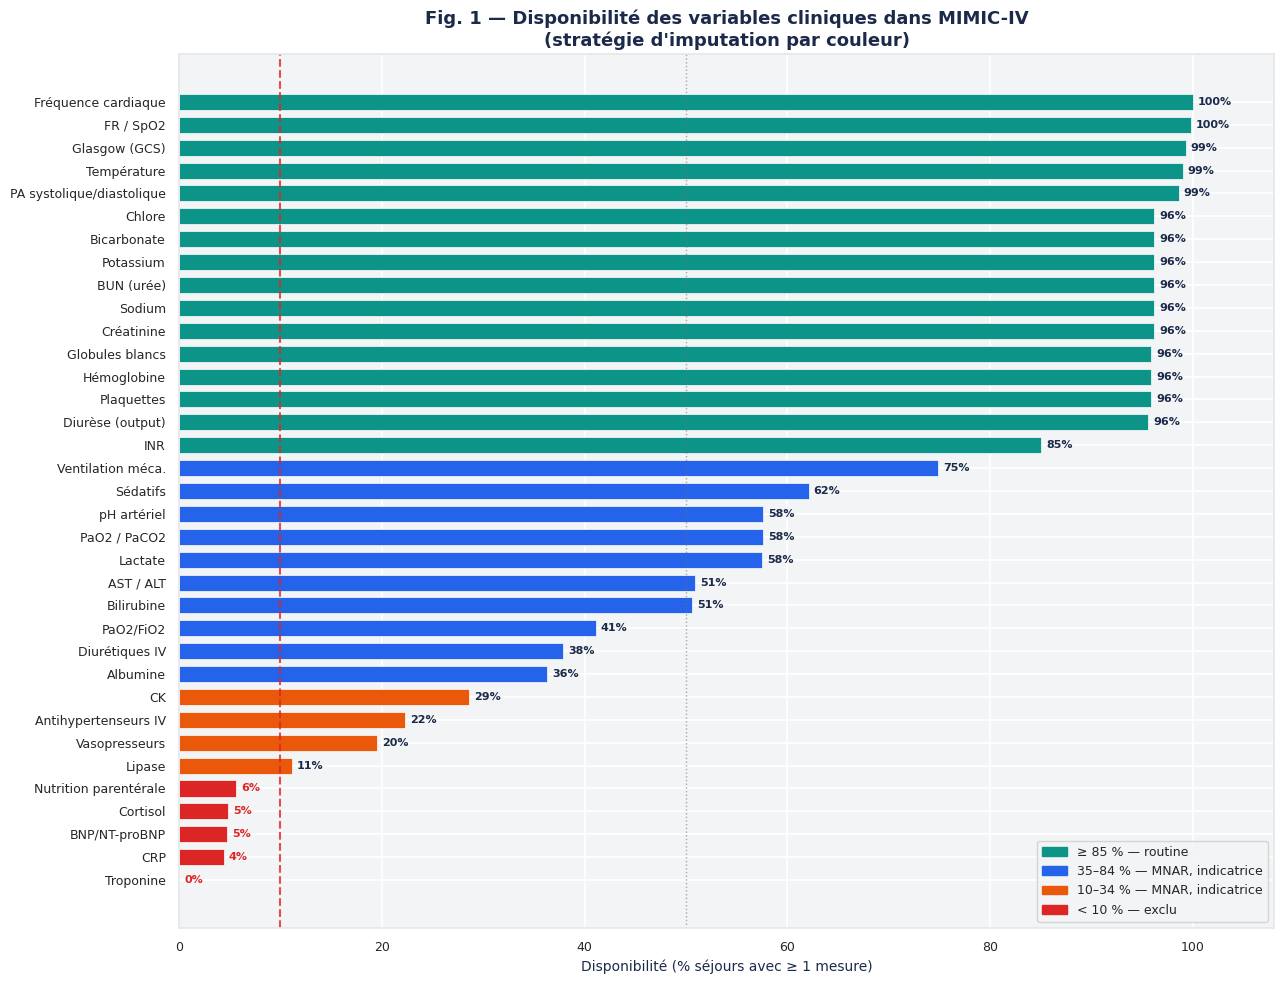

✓ Figure 1 sauvegardée


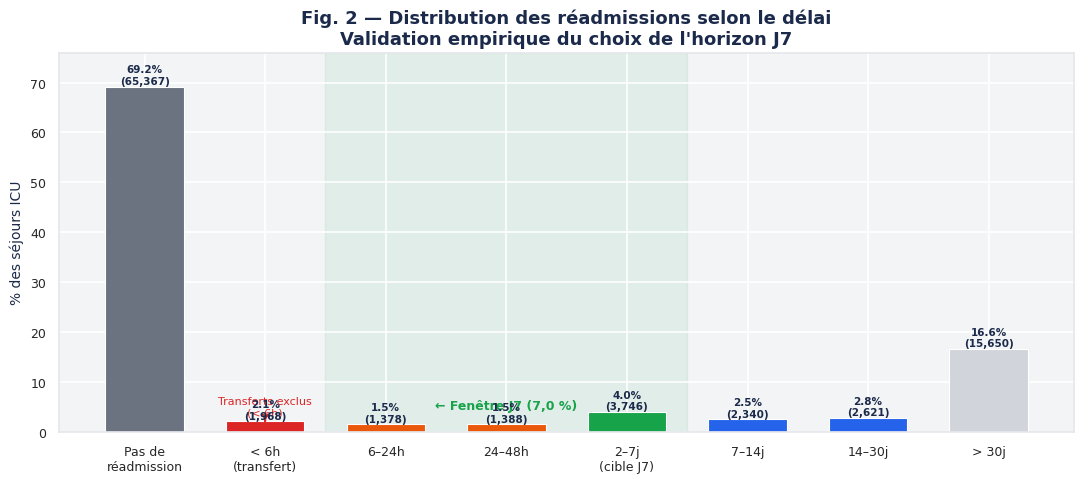

✓ Figure 2 sauvegardée


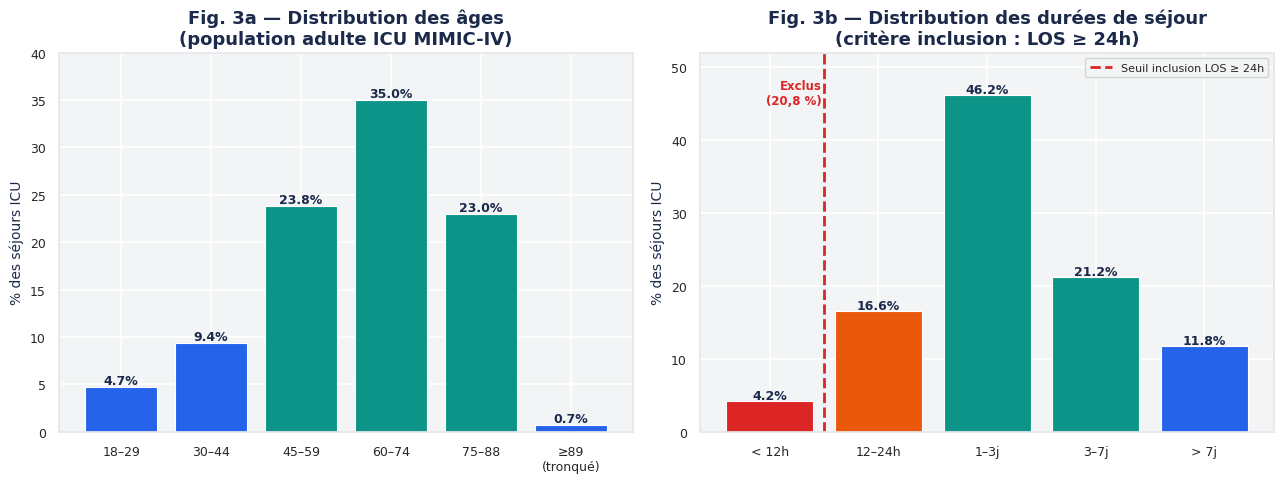

✓ Figure 3 sauvegardée


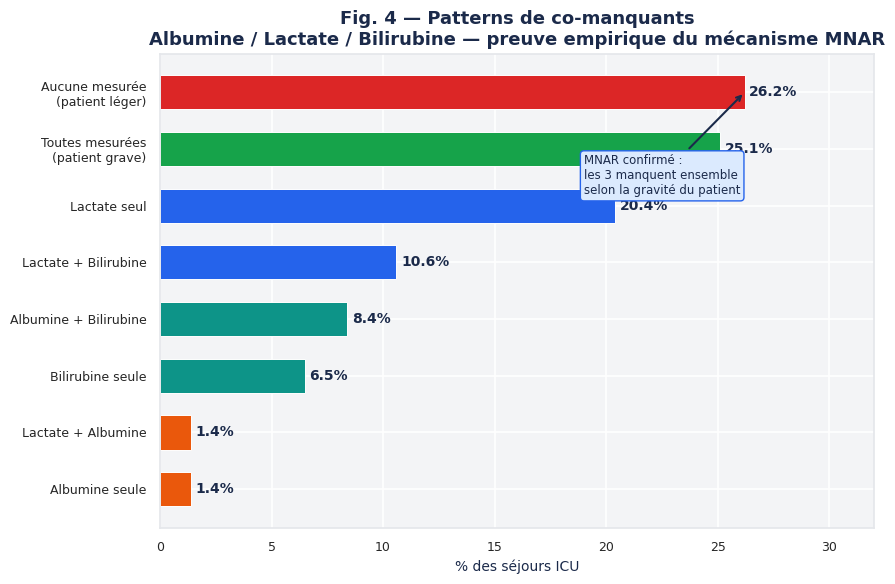

✓ Figure 4 sauvegardée


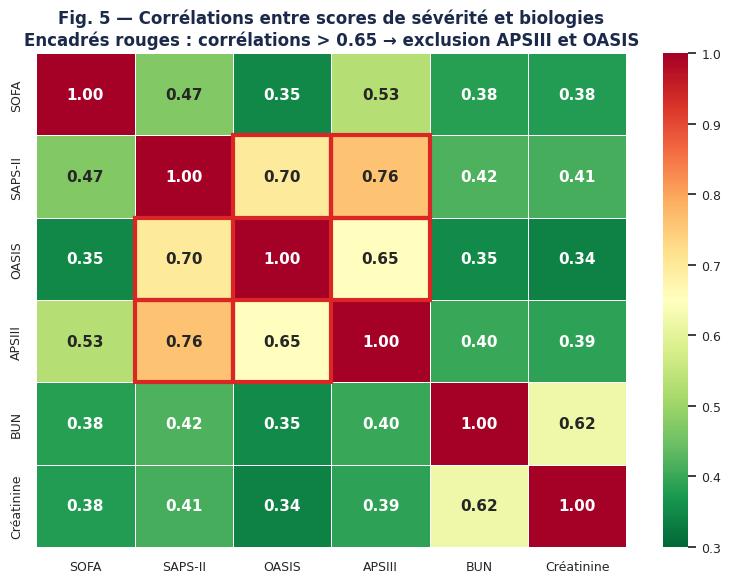

✓ Figure 5 sauvegardée


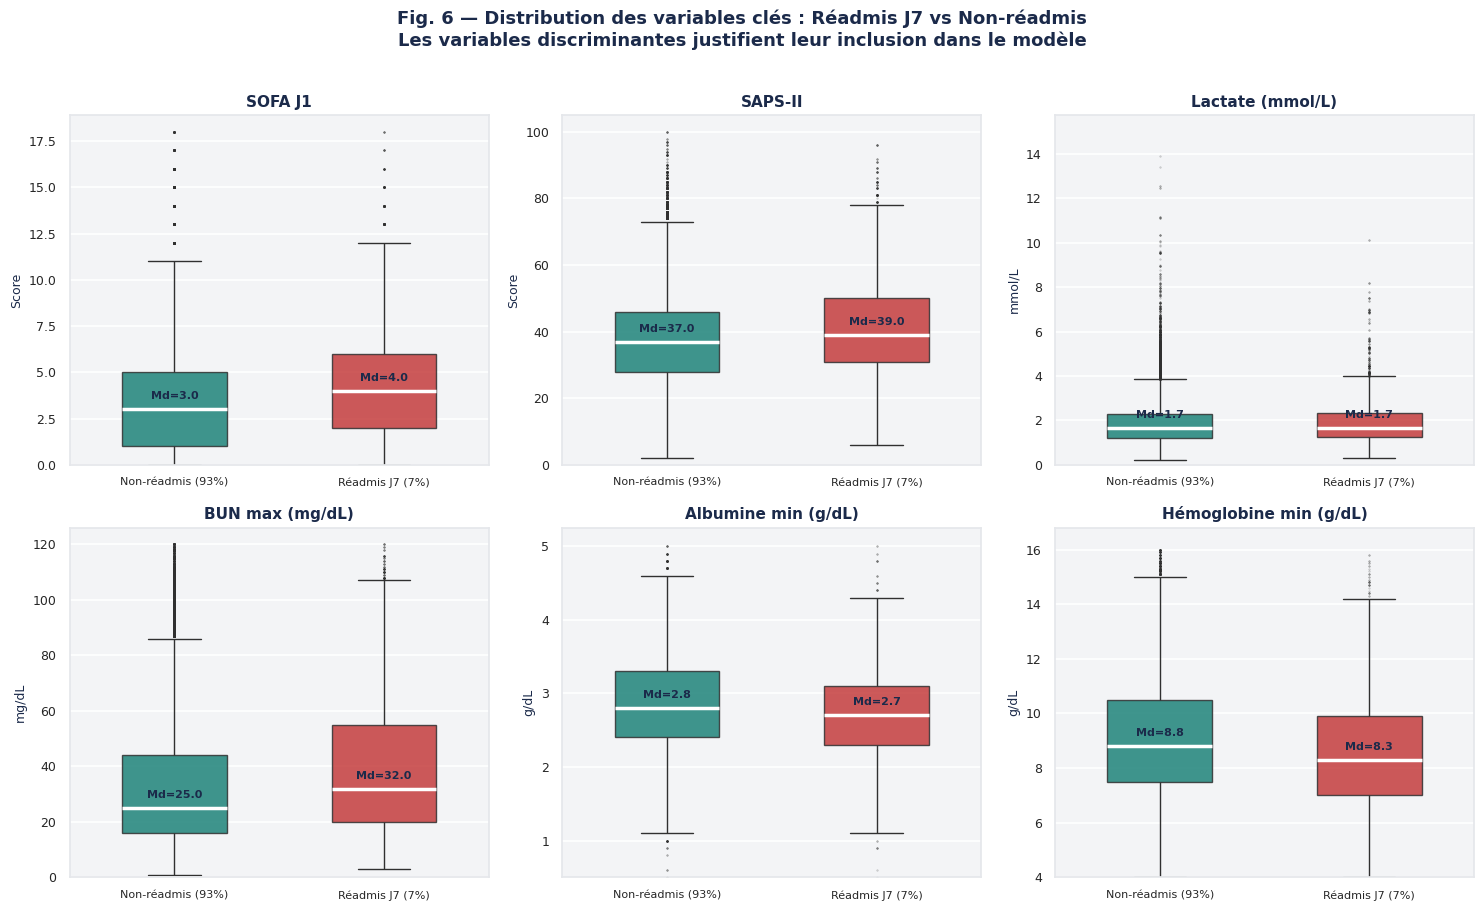

✓ Figure 6 sauvegardée


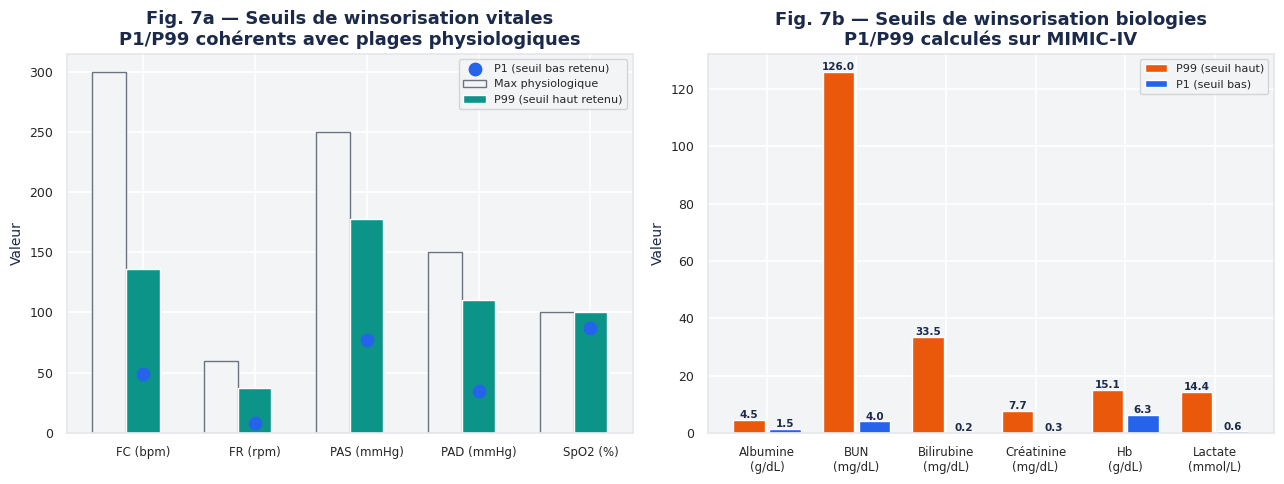

✓ Figure 7 sauvegardée

✓ Toutes les figures sauvegardées dans ./figures/
  fig1 — Disponibilité variables
  fig2 — Réadmissions par délai (validation J7)
  fig3 — Distribution âges + LOS
  fig4 — Co-manquants MNAR
  fig5 — Heatmap corrélations
  fig6 — Boxplots réadmis vs non-réadmis
  fig7 — Seuils winsorisation


In [8]:
# ============================================================
# VISUALISATIONS EDA — Figures complètes
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Palette et style ─────────────────────────────────────────
NAVY    = '#1B2A4A'
BLUE    = '#2563EB'
TEAL    = '#0D9488'
ORANGE  = '#EA580C'
RED     = '#DC2626'
GREEN   = '#16A34A'
LGRAY   = '#F3F4F6'
GRAY    = '#6B7280'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LGRAY,
    'axes.edgecolor':   '#E5E7EB',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  NAVY,
    'axes.labelsize':   10,
    'axes.labelcolor':  NAVY,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
})

import os
os.makedirs('figures', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Disponibilité des variables (toutes)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 10))

avail_data = {
    'Fréquence cardiaque':       100.0,
    'FR / SpO2':                  99.8,
    'Glasgow (GCS)':              99.3,
    'PA systolique/diastolique':  98.6,
    'Température':                99.0,
    'Chlore':                     96.2,
    'Bicarbonate':                96.2,
    'Potassium':                  96.2,
    'BUN (urée)':                 96.2,
    'Sodium':                     96.2,
    'Créatinine':                 96.2,
    'Globules blancs':            95.9,
    'Hémoglobine':                95.9,
    'Plaquettes':                 95.9,
    'Diurèse (output)':           95.6,
    'INR':                        85.0,
    'Ventilation méca.':          74.9,
    'Sédatifs':                   62.1,
    'pH artériel':                57.6,
    'Lactate':                    57.5,
    'PaO2 / PaCO2':               57.6,
    'AST / ALT':                  50.9,
    'Bilirubine':                 50.6,
    'PaO2/FiO2':                  41.1,
    'Diurétiques IV':             37.9,
    'Albumine':                   36.3,
    'CK':                         28.6,
    'Antihypertenseurs IV':       22.3,
    'Vasopresseurs':              19.5,
    'Lipase':                     11.1,
    'Nutrition parentérale':       5.6,
    'CRP':                         4.4,
    'BNP/NT-proBNP':               4.7,
    'Cortisol':                    4.8,
    'Troponine':                   0.0,
}

vars_sorted = sorted(avail_data.items(), key=lambda x: x[1], reverse=True)
labels = [v[0] for v in vars_sorted]
values = [v[1] for v in vars_sorted]
colors = []
for v in values:
    if v >= 85:
        colors.append(TEAL)
    elif v >= 35:
        colors.append(BLUE)
    elif v >= 10:
        colors.append(ORANGE)
    else:
        colors.append(RED)

bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.5, height=0.7)

ax.axvline(x=10, color=RED, linestyle='--', linewidth=1.5, alpha=0.8, label='Seuil minimum 10 %')
ax.axvline(x=50, color=GRAY, linestyle=':', linewidth=1, alpha=0.6, label='Seuil MNAR 50 %')

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8,
            color=NAVY if val >= 10 else RED, fontweight='bold')

patches = [
    mpatches.Patch(color=TEAL,   label='≥ 85 % — routine'),
    mpatches.Patch(color=BLUE,   label='35–84 % — MNAR, indicatrice'),
    mpatches.Patch(color=ORANGE, label='10–34 % — MNAR, indicatrice'),
    mpatches.Patch(color=RED,    label='< 10 % — exclu'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Disponibilité (% séjours avec ≥ 1 mesure)', fontsize=10)
ax.set_title('Fig. 1 — Disponibilité des variables cliniques dans MIMIC-IV\n'
             '(stratégie d\'imputation par couleur)', fontsize=13)
ax.set_xlim(0, 108)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig1_disponibilite_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Distribution des réadmissions par délai
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))

delais    = ['Pas de\nréadmission', '< 6h\n(transfert)', '6–24h', '24–48h',
             '2–7j\n(cible J7)', '7–14j', '14–30j', '> 30j']
nb        = [65367, 1968, 1378, 1388, 3746, 2340, 2621, 15650]
pcts      = [69.2, 2.1, 1.5, 1.5, 4.0, 2.5, 2.8, 16.6]
bar_colors= [GRAY, RED, ORANGE, ORANGE, GREEN, BLUE, BLUE, '#D1D5DB']

bars = ax.bar(delais, pcts, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.65)

ax.axvspan(1.5, 4.5, alpha=0.08, color=GREEN, zorder=0)
ax.text(3, 4.6, '← Fenêtre J7 (7,0 %)', color=GREEN, fontsize=9,
        fontweight='bold', ha='center')

ax.annotate('Transferts exclus\n(< 6h)', xy=(1, 2.1), xytext=(1, 3.3),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            fontsize=8, color=RED, ha='center')

for bar, pct, n in zip(bars, pcts, nb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{pct}%\n({n:,})', ha='center', va='bottom',
            fontsize=7.5, color=NAVY, fontweight='bold')

ax.set_ylabel('% des séjours ICU', fontsize=10)
ax.set_title('Fig. 2 — Distribution des réadmissions selon le délai\n'
             'Validation empirique du choix de l\'horizon J7', fontsize=13)
ax.set_ylim(0, 76)
plt.tight_layout()
plt.savefig('figures/fig2_readmission_delai.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Distribution des âges et LOS
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_labels = ['18–29', '30–44', '45–59', '60–74', '75–88', '≥89\n(tronqué)']
age_counts = [4412, 8867, 22515, 33022, 21681, 679]
age_pcts   = [4.7, 9.4, 23.8, 35.0, 23.0, 0.7]

axes[0].bar(age_labels, age_pcts,
            color=[TEAL if i in [2,3,4] else BLUE for i in range(len(age_labels))],
            edgecolor='white', linewidth=0.8)
for i, (pct, n) in enumerate(zip(age_pcts, age_counts)):
    axes[0].text(i, pct + 0.3, f'{pct}%', ha='center', fontsize=9,
                 fontweight='bold', color=NAVY)
axes[0].set_ylabel('% des séjours ICU')
axes[0].set_title('Fig. 3a — Distribution des âges\n(population adulte ICU MIMIC-IV)')
axes[0].set_ylim(0, 40)

los_labels = ['< 12h', '12–24h', '1–3j', '3–7j', '> 7j']
los_pcts   = [4.2, 16.6, 46.2, 21.2, 11.8]
colors_los = [RED, ORANGE, TEAL, TEAL, BLUE]

axes[1].bar(los_labels, los_pcts, color=colors_los, edgecolor='white', linewidth=0.8)
axes[1].axvline(x=0.5, color=RED, linestyle='--', linewidth=2,
                label='Seuil inclusion LOS ≥ 24h')
axes[1].text(0.48, 45, 'Exclus\n(20,8 %)', ha='right', color=RED,
             fontsize=8.5, fontweight='bold')

for i, pct in enumerate(los_pcts):
    axes[1].text(i, pct + 0.3, f'{pct}%', ha='center', fontsize=9,
                 fontweight='bold', color=NAVY)
axes[1].set_ylabel('% des séjours ICU')
axes[1].set_title('Fig. 3b — Distribution des durées de séjour\n'
                  '(critère inclusion : LOS ≥ 24h)')
axes[1].set_ylim(0, 52)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig3_age_los.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 4 — Patterns de co-manquants MNAR
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

patterns = [
    'Aucune mesurée\n(patient léger)',
    'Toutes mesurées\n(patient grave)',
    'Lactate seul',
    'Lactate + Bilirubine',
    'Albumine + Bilirubine',
    'Bilirubine seule',
    'Lactate + Albumine',
    'Albumine seule',
]
pcts_comiss  = [26.2, 25.1, 20.4, 10.6, 8.4, 6.5, 1.4, 1.4]
colors_comiss= [RED, GREEN, BLUE, BLUE, TEAL, TEAL, ORANGE, ORANGE]

bars = ax.barh(patterns, pcts_comiss, color=colors_comiss,
               edgecolor='white', linewidth=0.7, height=0.6)

for bar, pct in zip(bars, pcts_comiss):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, fontweight='bold', color=NAVY)

ax.set_xlabel('% des séjours ICU', fontsize=10)
ax.set_title('Fig. 4 — Patterns de co-manquants\n'
             'Albumine / Lactate / Bilirubine — preuve empirique du mécanisme MNAR',
             fontsize=13)
ax.set_xlim(0, 32)
ax.invert_yaxis()

ax.annotate('MNAR confirmé :\nles 3 manquent ensemble\nselon la gravité du patient',
            xy=(26.2, 0), xytext=(19, 1.8),
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.5),
            fontsize=8.5, color=NAVY,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#DBEAFE', edgecolor=BLUE))

plt.tight_layout()
plt.savefig('figures/fig4_comissing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 4 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 5 — Heatmap corrélations scores de sévérité
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

scores_names = ['SOFA', 'SAPS-II', 'OASIS', 'APSIII', 'BUN', 'Créatinine']
corr_matrix  = np.array([
    [1.000, 0.472, 0.349, 0.532, 0.384, 0.378],
    [0.472, 1.000, 0.699, 0.762, 0.420, 0.410],
    [0.349, 0.699, 1.000, 0.652, 0.350, 0.340],
    [0.532, 0.762, 0.652, 1.000, 0.400, 0.390],
    [0.384, 0.420, 0.350, 0.400, 1.000, 0.619],
    [0.378, 0.410, 0.340, 0.390, 0.619, 1.000],
])

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            xticklabels=scores_names, yticklabels=scores_names,
            vmin=0.3, vmax=1.0, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 11, 'weight': 'bold'})

for i, j in [(1,2), (1,3), (2,3)]:
    ax.add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor=RED, lw=3))
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=RED, lw=3))

ax.set_title('Fig. 5 — Corrélations entre scores de sévérité et biologies\n'
             'Encadrés rouges : corrélations > 0.65 → exclusion APSIII et OASIS',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 5 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 6 — Boxplots réadmis vs non-réadmis
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

variables = [
    ('sofa',         'SOFA J1',               0,   18,  'Score'),
    ('sapsii',       'SAPS-II',               0,  100,  'Score'),
    ('lactate_mean', 'Lactate (mmol/L)',       0,   15,  'mmol/L'),
    ('bun_max',      'BUN max (mg/dL)',        0,  120,  'mg/dL'),
    ('albumin_min',  'Albumine min (g/dL)',   0.5,   5,  'g/dL'),
    ('hb_min',       'Hémoglobine min (g/dL)', 4,   16,  'g/dL'),
]

# Fix palette seaborn : utiliser des labels string
df_box['readmit_str'] = df_box['readmit_7d'].map({
    0: 'Non-réadmis (93%)',
    1: 'Réadmis J7 (7%)'
})
palette_str = {'Non-réadmis (93%)': TEAL, 'Réadmis J7 (7%)': RED}
order_str   = ['Non-réadmis (93%)', 'Réadmis J7 (7%)']

for ax, (col, title, ymin, ymax, unit) in zip(axes, variables):
    df_plot = df_box[[col, 'readmit_7d', 'readmit_str']].dropna()
    df_plot = df_plot[df_plot[col].between(ymin, ymax)]

    med0 = df_plot[df_plot['readmit_7d']==0][col].median()
    med1 = df_plot[df_plot['readmit_7d']==1][col].median()

    sns.boxplot(data=df_plot, x='readmit_str', y=col,
                order=order_str, palette=palette_str,
                ax=ax, width=0.5,
                flierprops=dict(marker='.', markersize=1, alpha=0.3),
                medianprops=dict(color='white', linewidth=2.5),
                boxprops=dict(alpha=0.85))

    ax.set_xticklabels(order_str, fontsize=8)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=11, fontweight='bold', color=NAVY)
    ax.set_ylim(ymin, ymax * 1.05)

    offset = (ymax - ymin) * 0.03
    ax.text(0, med0 + offset, f'Md={med0:.1f}', ha='center',
            fontsize=8, color=NAVY, fontweight='bold')
    ax.text(1, med1 + offset, f'Md={med1:.1f}', ha='center',
            fontsize=8, color=NAVY, fontweight='bold')

fig.suptitle('Fig. 6 — Distribution des variables clés : Réadmis J7 vs Non-réadmis\n'
             'Les variables discriminantes justifient leur inclusion dans le modèle',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig6_boxplots_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 6 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIGURE 7 — Seuils de winsorisation
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 7a — Vitales
vit_vars       = ['FC (bpm)', 'FR (rpm)', 'PAS (mmHg)', 'PAD (mmHg)', 'SpO2 (%)']
vit_p1         = [49, 8, 77, 35, 87]
vit_p99        = [136, 37, 178, 110, 100]
vit_physio_max = [300, 60, 250, 150, 100]

x = np.arange(len(vit_vars))
w = 0.3

axes[0].bar(x - w, vit_physio_max, width=w, color=LGRAY,
            edgecolor=GRAY, label='Max physiologique')
axes[0].bar(x, vit_p99, width=w, color=TEAL,
            edgecolor='white', label='P99 (seuil haut retenu)')
axes[0].scatter(x, vit_p1, color=BLUE, zorder=5, s=80, label='P1 (seuil bas retenu)')

axes[0].set_xticks(x)
axes[0].set_xticklabels(vit_vars, fontsize=8.5)
axes[0].set_ylabel('Valeur')
axes[0].set_title('Fig. 7a — Seuils de winsorisation vitales\n'
                  'P1/P99 cohérents avec plages physiologiques')
axes[0].legend(fontsize=8)

# 7b — Biologies
bio_vars = ['Albumine\n(g/dL)', 'BUN\n(mg/dL)', 'Bilirubine\n(mg/dL)',
            'Créatinine\n(mg/dL)', 'Hb\n(g/dL)', 'Lactate\n(mmol/L)']
bio_p1   = [1.5, 4.0, 0.2, 0.3, 6.3, 0.6]
bio_p99  = [4.5, 126.0, 33.5, 7.7, 15.1, 14.4]

x2 = np.arange(len(bio_vars))
axes[1].bar(x2 - 0.2, bio_p99, width=0.35, color=ORANGE,
            edgecolor='white', label='P99 (seuil haut)')
axes[1].bar(x2 + 0.2, bio_p1,  width=0.35, color=BLUE,
            edgecolor='white', label='P1 (seuil bas)')

for i, (p1, p99) in enumerate(zip(bio_p1, bio_p99)):
    axes[1].text(i - 0.2, p99 + 0.5, f'{p99}', ha='center',
                 fontsize=7.5, color=NAVY, fontweight='bold')
    axes[1].text(i + 0.2, p1  + 0.5, f'{p1}',  ha='center',
                 fontsize=7.5, color=NAVY, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(bio_vars, fontsize=8.5)
axes[1].set_ylabel('Valeur')
axes[1].set_title('Fig. 7b — Seuils de winsorisation biologies\n'
                  'P1/P99 calculés sur MIMIC-IV')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig7_winsorisation_seuils.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 7 sauvegardée")

# ── Récapitulatif ─────────────────────────────────────────────
print("\n" + "="*50)
print("✓ Toutes les figures sauvegardées dans ./figures/")
print("  fig1 — Disponibilité variables")
print("  fig2 — Réadmissions par délai (validation J7)")
print("  fig3 — Distribution âges + LOS")
print("  fig4 — Co-manquants MNAR")
print("  fig5 — Heatmap corrélations")
print("  fig6 — Boxplots réadmis vs non-réadmis")
print("  fig7 — Seuils winsorisation")

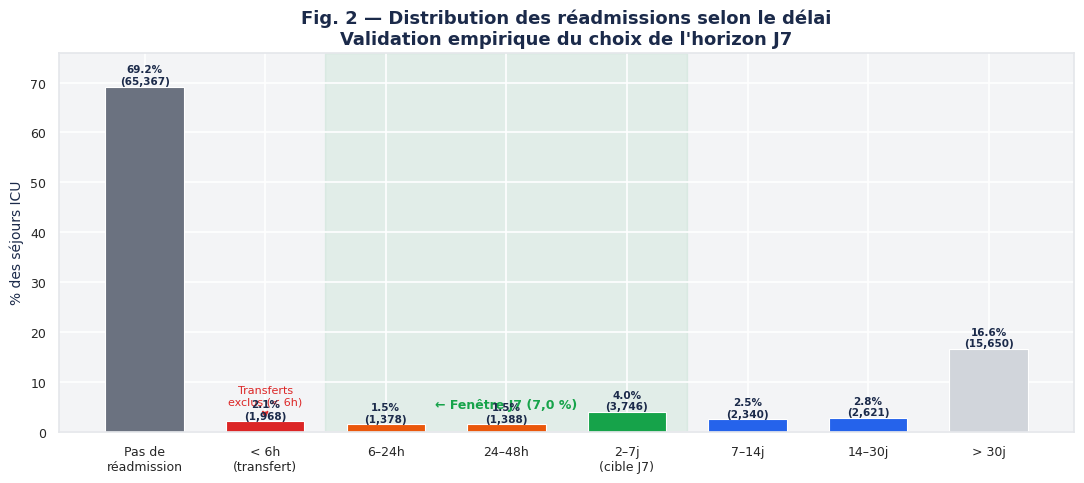

✓ Figure 2 corrigée


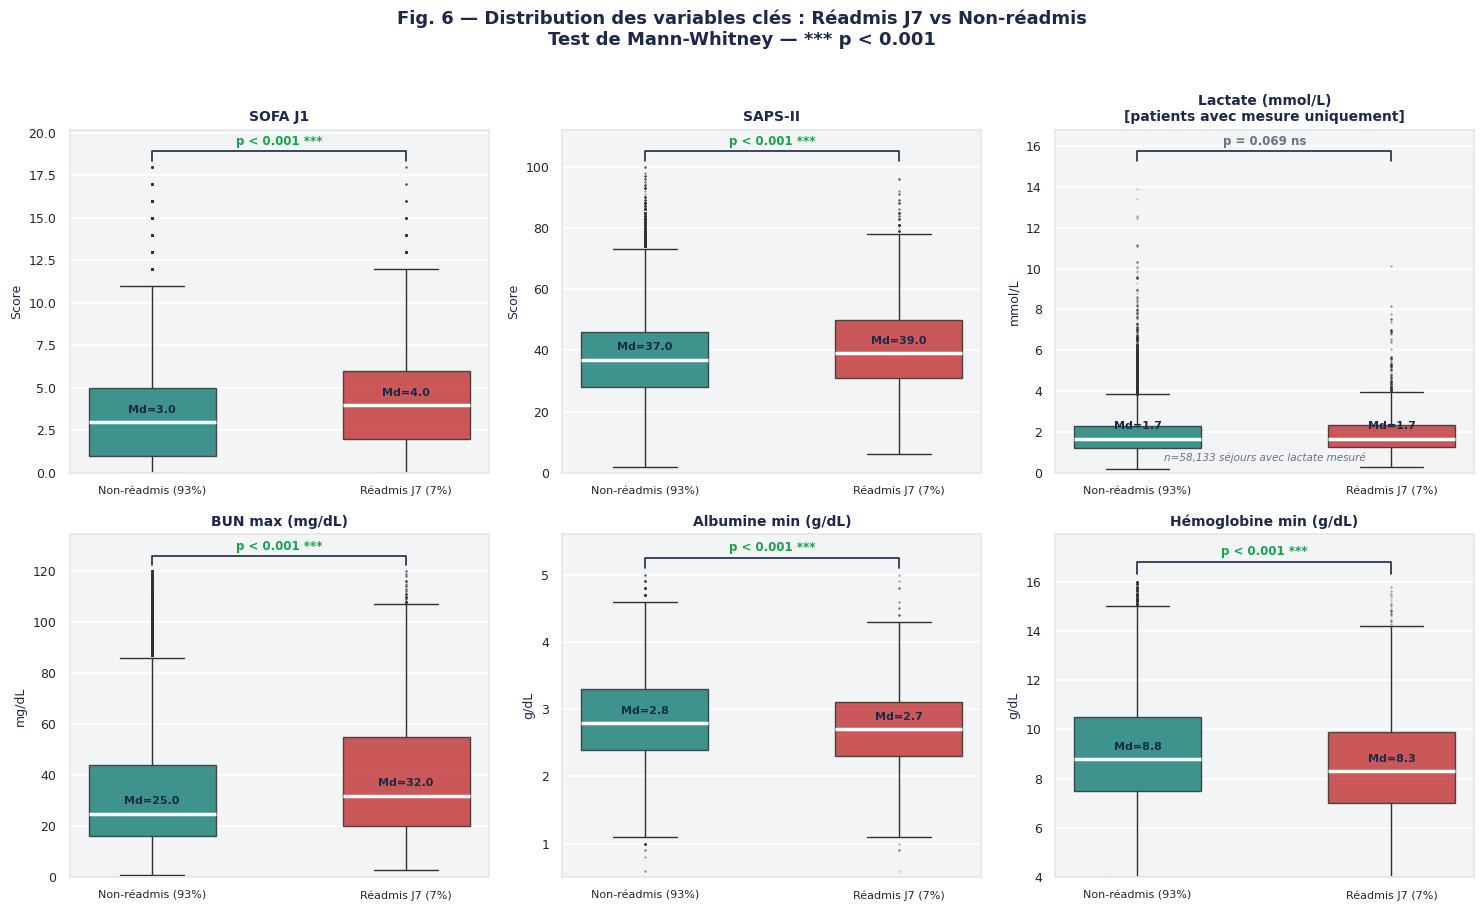

✓ Figure 6 corrigée


In [9]:
from scipy.stats import mannwhitneyu

# ══════════════════════════════════════════════════════════════
# FIG. 2 CORRIGÉE — fond vert décalé
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))

delais    = ['Pas de\nréadmission', '< 6h\n(transfert)', '6–24h', '24–48h',
             '2–7j\n(cible J7)', '7–14j', '14–30j', '> 30j']
nb        = [65367, 1968, 1378, 1388, 3746, 2340, 2621, 15650]
pcts      = [69.2, 2.1, 1.5, 1.5, 4.0, 2.5, 2.8, 16.6]
bar_colors= [GRAY, RED, ORANGE, ORANGE, GREEN, BLUE, BLUE, '#D1D5DB']

bars = ax.bar(delais, pcts, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.65)

# Fond vert commence à 1.5 (après barre "< 6h") jusqu'à 4.5 (fin barre "2–7j")
ax.axvspan(1.5, 4.5, alpha=0.08, color=GREEN, zorder=0)
ax.text(3.0, 4.8, '← Fenêtre J7 (7,0 %)', color=GREEN,
        fontsize=9, fontweight='bold', ha='center')

# Annotation transferts — déplacée au dessus pour éviter chevauchement
ax.annotate('Transferts\nexclus (< 6h)',
            xy=(1, 2.1), xytext=(1, 5.5),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            fontsize=8, color=RED, ha='center')

for bar, pct, n in zip(bars, pcts, nb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{pct}%\n({n:,})', ha='center', va='bottom',
            fontsize=7.5, color=NAVY, fontweight='bold')

ax.set_ylabel('% des séjours ICU', fontsize=10)
ax.set_title('Fig. 2 — Distribution des réadmissions selon le délai\n'
             'Validation empirique du choix de l\'horizon J7', fontsize=13)
ax.set_ylim(0, 76)
plt.tight_layout()
plt.savefig('figures/fig2_readmission_delai.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 corrigée")

# ══════════════════════════════════════════════════════════════
# FIG. 6 CORRIGÉE — p-values + lactate filtré aux mesurés
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

variables = [
    ('sofa',         'SOFA J1',               0,   18,  'Score',   False),
    ('sapsii',       'SAPS-II',               0,  100,  'Score',   False),
    ('lactate_mean', 'Lactate (mmol/L)\n[patients avec mesure uniquement]',
                                              0,   15,  'mmol/L',  True),
    ('bun_max',      'BUN max (mg/dL)',        0,  120,  'mg/dL',   False),
    ('albumin_min',  'Albumine min (g/dL)',   0.5,   5,  'g/dL',    False),
    ('hb_min',       'Hémoglobine min (g/dL)', 4,   16,  'g/dL',    False),
]

df_box['readmit_str'] = df_box['readmit_7d'].map({
    0: 'Non-réadmis (93%)',
    1: 'Réadmis J7 (7%)'
})
palette_str = {'Non-réadmis (93%)': TEAL, 'Réadmis J7 (7%)': RED}
order_str   = ['Non-réadmis (93%)', 'Réadmis J7 (7%)']

def pval_label(p):
    if p < 0.001:
        return 'p < 0.001 ***'
    elif p < 0.01:
        return f'p = {p:.3f} **'
    elif p < 0.05:
        return f'p = {p:.3f} *'
    else:
        return f'p = {p:.3f} ns'

for ax, (col, title, ymin, ymax, unit, filter_measured) in zip(axes, variables):

    df_plot = df_box[[col, 'readmit_7d', 'readmit_str']].copy()

    # Pour le lactate : garder uniquement les patients avec mesure réelle
    if filter_measured:
        df_plot = df_plot.dropna(subset=[col])
        n_total = len(df_plot)
        n_readmit = df_plot['readmit_7d'].sum()
    else:
        df_plot = df_plot.dropna(subset=[col])

    df_plot = df_plot[df_plot[col].between(ymin, ymax)]

    med0 = df_plot[df_plot['readmit_7d']==0][col].median()
    med1 = df_plot[df_plot['readmit_7d']==1][col].median()

    # Mann-Whitney U test
    g0 = df_plot[df_plot['readmit_7d']==0][col].values
    g1 = df_plot[df_plot['readmit_7d']==1][col].values
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')

    sns.boxplot(data=df_plot, x='readmit_str', y=col,
                order=order_str, palette=palette_str,
                ax=ax, width=0.5,
                flierprops=dict(marker='.', markersize=1, alpha=0.3),
                medianprops=dict(color='white', linewidth=2.5),
                boxprops=dict(alpha=0.85))

    ax.set_xticklabels(order_str, fontsize=8)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=10, fontweight='bold', color=NAVY)
    ax.set_ylim(ymin, ymax * 1.12)

    # Médianes
    offset = (ymax - ymin) * 0.03
    ax.text(0, med0 + offset, f'Md={med0:.1f}', ha='center',
            fontsize=8, color=NAVY, fontweight='bold')
    ax.text(1, med1 + offset, f'Md={med1:.1f}', ha='center',
            fontsize=8, color=NAVY, fontweight='bold')

    # Barre de significativité + p-value
    bar_y = ymax * 1.05
    ax.plot([0, 0, 1, 1],
            [bar_y * 0.97, bar_y, bar_y, bar_y * 0.97],
            color=NAVY, linewidth=1.2)
    ax.text(0.5, bar_y * 1.01, pval_label(p),
            ha='center', va='bottom', fontsize=8.5,
            color=GREEN if p < 0.05 else GRAY,
            fontweight='bold')

    # Note n pour le lactate
    if filter_measured:
        ax.text(0.5, ymin + (ymax-ymin)*0.04,
                f'n={len(df_plot):,} séjours avec lactate mesuré',
                ha='center', fontsize=7.5, color=GRAY, style='italic',
                transform=ax.transData)

fig.suptitle('Fig. 6 — Distribution des variables clés : Réadmis J7 vs Non-réadmis\n'
             'Test de Mann-Whitney — *** p < 0.001',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig6_boxplots_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 6 corrigée")

In [8]:
query_cohort_v4 = """
WITH

base AS (
    SELECT
        i.stay_id,
        i.subject_id,
        i.hadm_id,
        i.intime,
        i.outtime,
        i.first_careunit,
        TIMESTAMP_DIFF(i.outtime, i.intime, HOUR)        AS los_hours,
        TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) / 24.0 AS los_days,
        ROW_NUMBER() OVER (
            PARTITION BY i.hadm_id
            ORDER BY i.intime
        ) AS icu_rank_in_hadm,
        ROW_NUMBER() OVER (
            PARTITION BY i.subject_id
            ORDER BY i.intime
        ) AS icu_rank_patient
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
),

hadm_info AS (
    SELECT
        a.hadm_id,
        a.subject_id,
        a.admittime,
        a.dischtime,
        a.hospital_expire_flag,
        p.anchor_age,
        p.anchor_year_group,
        p.dod,
        CASE
            WHEN UPPER(a.admission_location) LIKE '%EMERGENCY%' THEN 1
            ELSE 0
        END AS from_ed
    FROM `physionet-data.mimiciv_3_1_hosp.admissions` a
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON a.subject_id = p.subject_id
),

icu_deaths AS (
    SELECT DISTINCT i.stay_id
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON i.subject_id = p.subject_id
    WHERE p.dod IS NOT NULL
      AND p.dod BETWEEN i.intime
                    AND TIMESTAMP_ADD(i.outtime, INTERVAL 6 HOUR)
),

cohort_included AS (
    SELECT
        b.stay_id,
        b.subject_id,
        b.hadm_id,
        b.intime,
        b.outtime,
        b.first_careunit,
        b.los_hours,
        b.los_days,
        b.icu_rank_in_hadm,
        b.icu_rank_patient,
        h.anchor_age        AS age,
        h.anchor_year_group,
        h.from_ed,
        h.admittime,
        h.dischtime,
        h.dod
    FROM base b
    JOIN hadm_info h
        ON  b.hadm_id    = h.hadm_id
        AND b.subject_id = h.subject_id
    WHERE
        h.anchor_age >= 18
        AND b.los_hours >= 24
        AND b.first_careunit IN (
            'Medical Intensive Care Unit (MICU)',
            'Medical/Surgical Intensive Care Unit (MICU/SICU)',
            'Cardiac Vascular Intensive Care Unit (CVICU)',  -- nom corrigé
            'Surgical Intensive Care Unit (SICU)',
            'Coronary Care Unit (CCU)',
            'Trauma SICU (TSICU)',
            'Neuro Intermediate',
            'Neuro Surgical Intensive Care Unit (Neuro SICU)'
        )
        AND b.icu_rank_in_hadm = 1
        AND b.stay_id NOT IN (SELECT stay_id FROM icu_deaths)
        AND h.hospital_expire_flag = 0
        AND b.outtime IS NOT NULL
        AND TIMESTAMP_DIFF(b.outtime, b.intime, MINUTE) > 0
),

next_icu AS (
    SELECT
        c.stay_id,
        MIN(i2.intime)                                   AS next_icu_intime,
        MIN(TIMESTAMP_DIFF(i2.intime, c.outtime, HOUR)) AS delta_hours_to_next_icu
    FROM cohort_included c
    JOIN `physionet-data.mimiciv_3_1_icu.icustays` i2
        ON  i2.subject_id = c.subject_id
        AND i2.hadm_id    = c.hadm_id
        AND i2.intime     > c.outtime
        AND i2.stay_id   != c.stay_id
    GROUP BY c.stay_id
)

SELECT
    c.stay_id,
    c.subject_id,
    c.hadm_id,
    c.intime,
    c.outtime,
    c.first_careunit,
    c.los_hours,
    c.los_days,
    c.age,
    c.from_ed,
    c.admittime,
    c.dischtime,
    c.icu_rank_patient,
    c.anchor_year_group,
    n.delta_hours_to_next_icu,

    CASE
        WHEN n.delta_hours_to_next_icu >= 6
         AND n.delta_hours_to_next_icu <= 168 THEN 1
        ELSE 0
    END AS readmit_7d,

    CASE
        WHEN n.delta_hours_to_next_icu >= 6
         AND n.delta_hours_to_next_icu <= 336 THEN 1
        ELSE 0
    END AS readmit_14d,

    CASE
        WHEN n.delta_hours_to_next_icu >= 6
         AND n.delta_hours_to_next_icu <= 720 THEN 1
        ELSE 0
    END AS readmit_30d

FROM cohort_included c
LEFT JOIN next_icu n ON n.stay_id = c.stay_id
ORDER BY c.subject_id, c.intime
"""

print("Lancement (2-3 min)...")
df_cohort = client.query(query_cohort_v4).to_dataframe()

n_total = len(df_cohort)
n_7d    = int(df_cohort['readmit_7d'].sum())
n_14d   = int(df_cohort['readmit_14d'].sum())
n_30d   = int(df_cohort['readmit_30d'].sum())

print(f"\n{'='*52}")
print(f"  COHORTE FINALE v4")
print(f"{'='*52}")
print(f"  Total séjours       : {n_total:>8,}")
print(f"  Patients uniques    : {df_cohort['subject_id'].nunique():>8,}")
print(f"{'─'*52}")
print(f"  Réadmissions J7     : {n_7d:>8,}  ({n_7d/n_total*100:.1f}%)")
print(f"  Réadmissions J14    : {n_14d:>8,}  ({n_14d/n_total*100:.1f}%)")
print(f"  Réadmissions J30    : {n_30d:>8,}  ({n_30d/n_total*100:.1f}%)")
print(f"{'─'*52}")
print(f"  LOS moyen (jours)   : {df_cohort['los_days'].mean():>8.2f}")
print(f"  Age moyen           : {df_cohort['age'].mean():>8.1f}")
print(f"  Depuis urgences     : {df_cohort['from_ed'].mean()*100:>7.1f}%")
print(f"{'─'*52}")
print(f"  Distribution unités ICU :")
units = (df_cohort['first_careunit'].value_counts(normalize=True)*100).round(1)
for unit, pct in units.items():
    short = unit.split('(')[-1].replace(')','').strip() if '(' in unit else unit
    print(f"    {short:<42} {pct:>5.1f}%")
print(f"{'─'*52}")
print(f"  Distribution temporelle + taux J7 :")
yg = df_cohort.groupby('anchor_year_group').agg(
    n=('stay_id','count'),
    readmit_7d_pct=('readmit_7d', lambda x: x.mean()*100)
).sort_index()
for grp, row in yg.iterrows():
    print(f"    {grp} : {int(row['n']):>6,} séjours  |  readmit_7d = {row['readmit_7d_pct']:.1f}%")

Lancement (2-3 min)...

  COHORTE FINALE v4
  Total séjours       :   59,260
  Patients uniques    :   47,467
────────────────────────────────────────────────────
  Réadmissions J7     :    3,144  (5.3%)
  Réadmissions J14    :    3,709  (6.3%)
  Réadmissions J30    :    3,922  (6.6%)
────────────────────────────────────────────────────
  LOS moyen (jours)   :     3.90
  Age moyen           :     62.8
  Depuis urgences     :    37.4%
────────────────────────────────────────────────────
  Distribution unités ICU :
    MICU                                        19.9%
    CVICU                                       19.8%
    MICU/SICU                                   15.3%
    SICU                                        13.8%
    CCU                                         11.4%
    TSICU                                       10.7%
    Neuro Intermediate                           7.5%
    Neuro SICU                                   1.6%
─────────────────────────────────────────────────

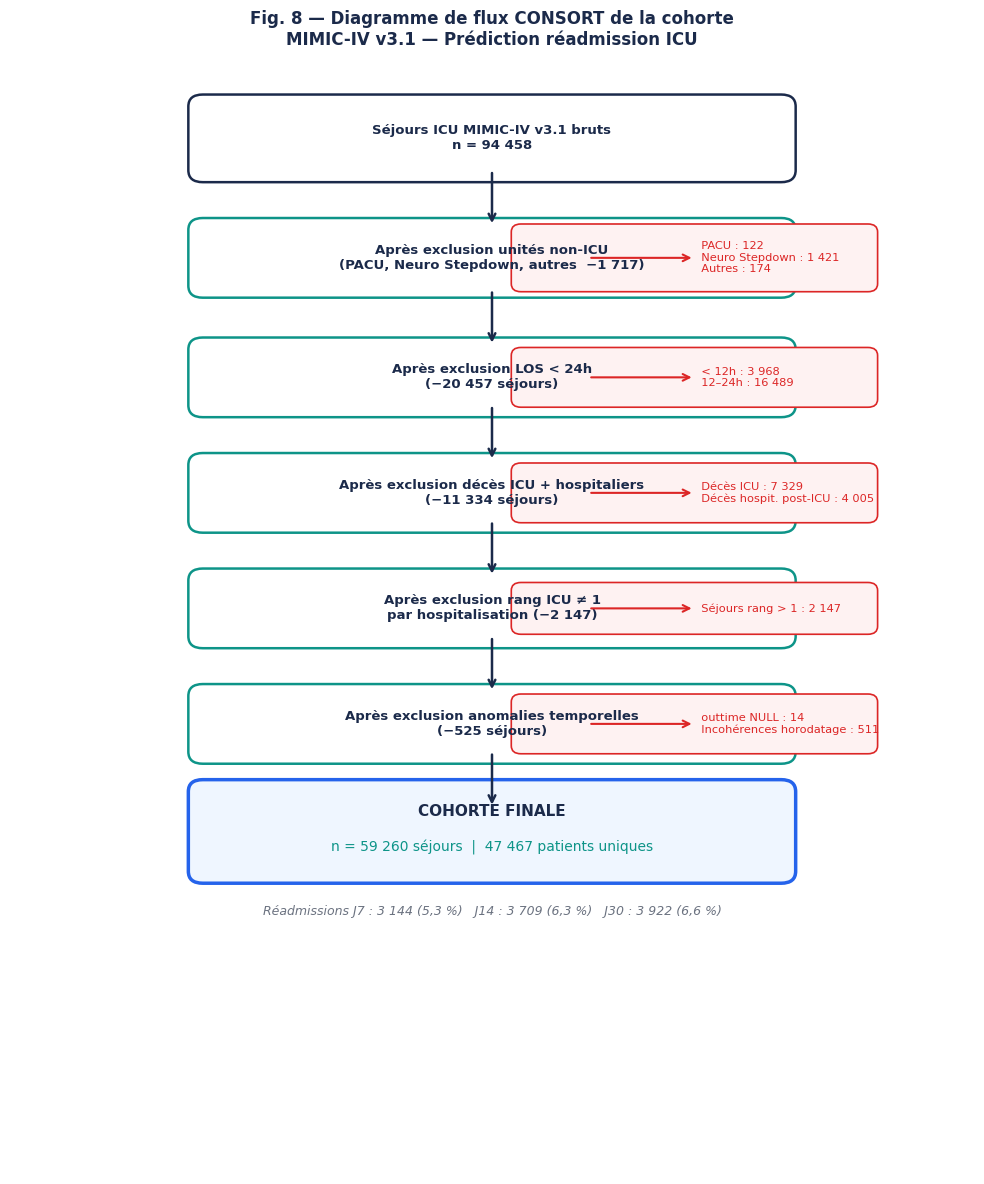

✓ Figure 8 sauvegardée


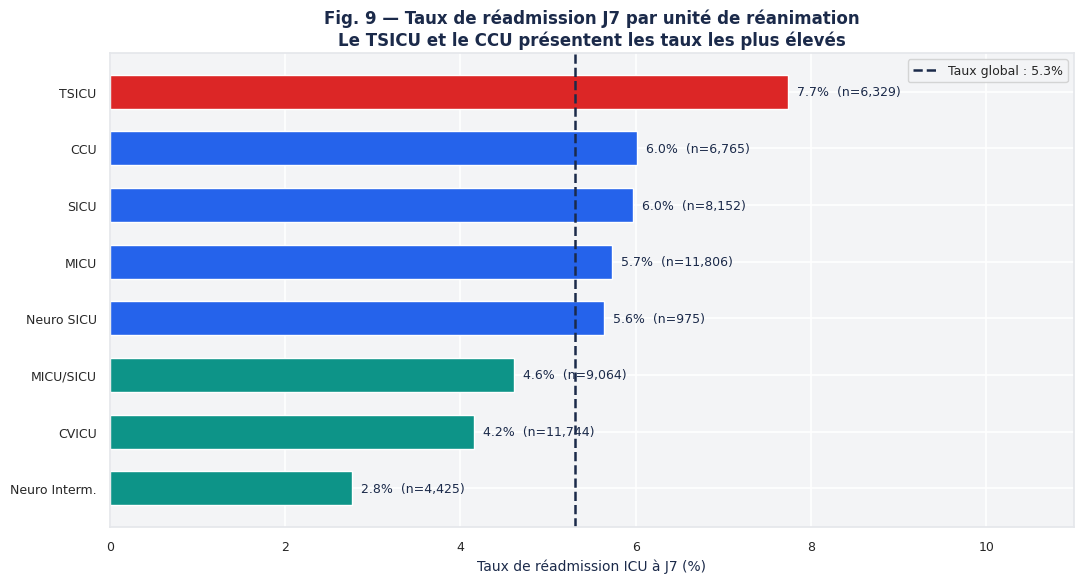

✓ Figure 9 sauvegardée


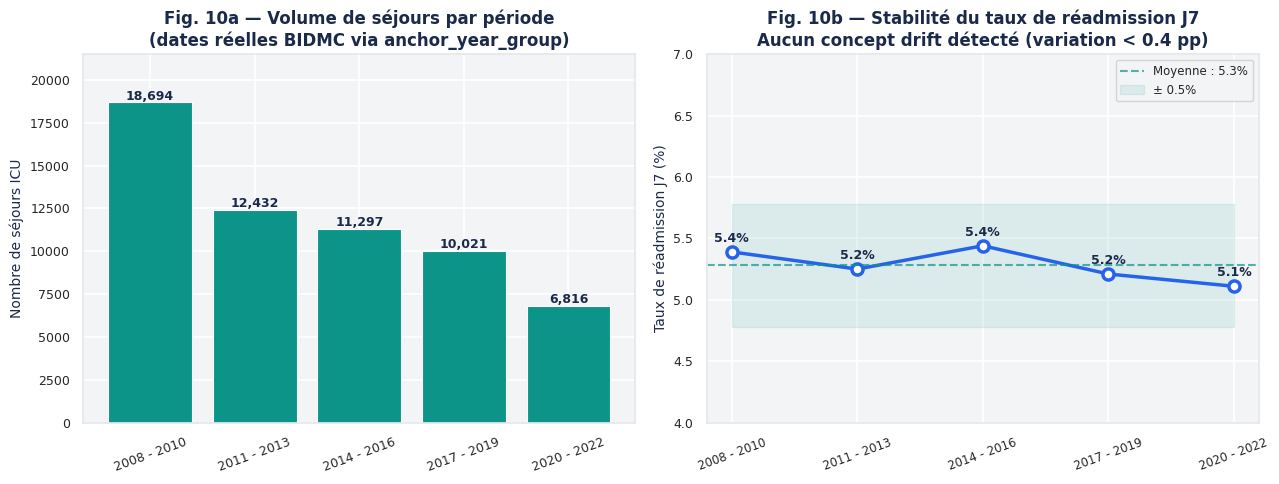

✓ Figure 10 sauvegardée


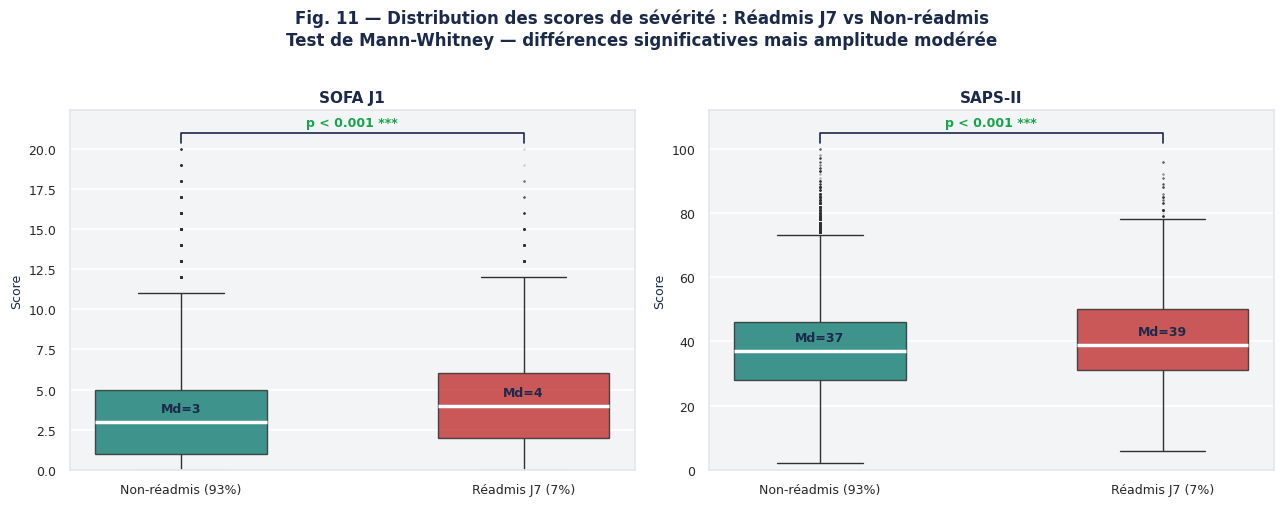

✓ Figure 11 sauvegardée


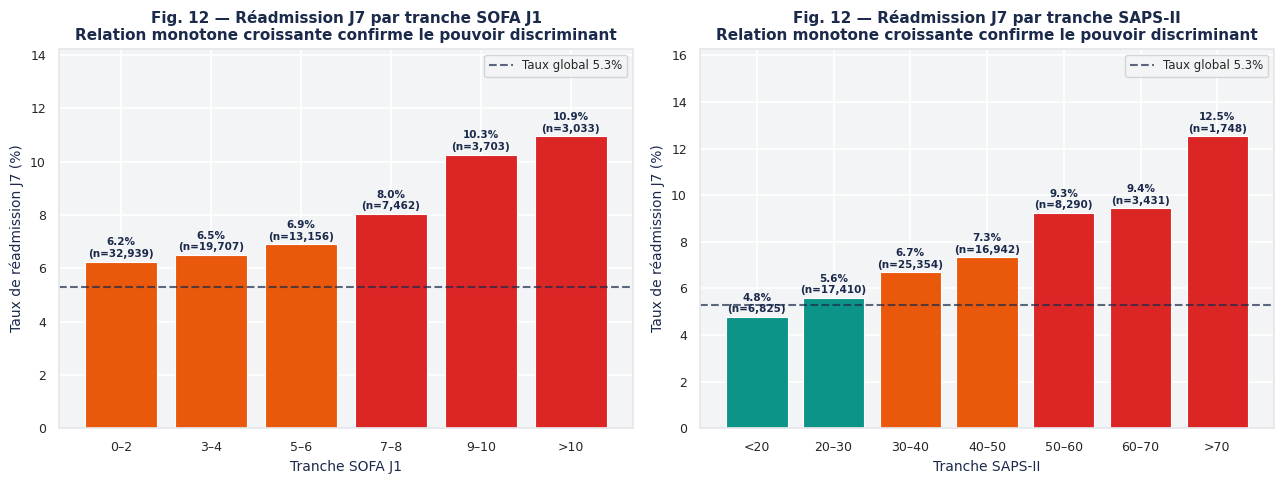

✓ Figure 12 sauvegardée

✓ Toutes les nouvelles figures sauvegardées :
  fig8  — Diagramme CONSORT
  fig9  — Taux J7 par unité ICU
  fig10 — Distribution temporelle
  fig11 — SOFA/SAPS-II réadmis vs non-réadmis
  fig12 — Taux J7 par tranche de sévérité


In [24]:
# ============================================================
# FIGURES EDA COMPLÉMENTAIRES — Fig 8, 9, 10, 11, 12
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import os

os.makedirs('figures', exist_ok=True)

NAVY   = '#1B2A4A'
BLUE   = '#2563EB'
TEAL   = '#0D9488'
ORANGE = '#EA580C'
RED    = '#DC2626'
GREEN  = '#16A34A'
LGRAY  = '#F3F4F6'
GRAY   = '#6B7280'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LGRAY,
    'axes.edgecolor':   '#E5E7EB',
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  NAVY,
    'axes.labelsize':   10,
    'axes.labelcolor':  NAVY,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
})

# ══════════════════════════════════════════════════════════════
# FIG 8 — Diagramme CONSORT de la cohorte
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

def consort_box(ax, x, y, w, h, text, color=NAVY, fontsize=9.5):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.15",
        facecolor='white', edgecolor=color, linewidth=1.8
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=NAVY,
            fontweight='bold', wrap=True,
            multialignment='center')

def excl_box(ax, x, y, w, h, text):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        facecolor='#FEF2F2', edgecolor=RED, linewidth=1.2
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha='left', va='center',
            fontsize=8.2, color=RED, multialignment='left')

def arrow_down(ax, x, y1, y2, color=NAVY):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

def arrow_right(ax, x1, x2, y, color=RED):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Boîtes principales
consort_box(ax, 5, 13,   6, 0.8,
    "Séjours ICU MIMIC-IV v3.1 bruts\nn = 94 458", NAVY)
arrow_down(ax, 5, 12.6, 11.9)

consort_box(ax, 5, 11.5, 6, 0.7,
    "Après exclusion unités non-ICU\n(PACU, Neuro Stepdown, autres  −1 717)", TEAL)
arrow_down(ax, 5, 11.1, 10.4)
excl_box(ax, 7.1, 11.5, 3.6, 0.65,
    "  PACU : 122\n  Neuro Stepdown : 1 421\n  Autres : 174")
arrow_right(ax, 6, 7.1, 11.5)

consort_box(ax, 5, 10.0, 6, 0.7,
    "Après exclusion LOS < 24h\n(−20 457 séjours)", TEAL)
arrow_down(ax, 5, 9.65, 8.95)
excl_box(ax, 7.1, 10.0, 3.6, 0.55,
    "  < 12h : 3 968\n  12–24h : 16 489")
arrow_right(ax, 6, 7.1, 10.0)

consort_box(ax, 5, 8.55, 6, 0.7,
    "Après exclusion décès ICU + hospitaliers\n(−11 334 séjours)", TEAL)
arrow_down(ax, 5, 8.2, 7.5)
excl_box(ax, 7.1, 8.55, 3.6, 0.55,
    "  Décès ICU : 7 329\n  Décès hospit. post-ICU : 4 005")
arrow_right(ax, 6, 7.1, 8.55)

consort_box(ax, 5, 7.1, 6, 0.7,
    "Après exclusion rang ICU ≠ 1\npar hospitalisation (−2 147)", TEAL)
arrow_down(ax, 5, 6.75, 6.05)
excl_box(ax, 7.1, 7.1, 3.6, 0.45,
    "  Séjours rang > 1 : 2 147")
arrow_right(ax, 6, 7.1, 7.1)

consort_box(ax, 5, 5.65, 6, 0.7,
    "Après exclusion anomalies temporelles\n(−525 séjours)", TEAL)
arrow_down(ax, 5, 5.3, 4.6)
excl_box(ax, 7.1, 5.65, 3.6, 0.55,
    "  outtime NULL : 14\n  Incohérences horodatage : 511")
arrow_right(ax, 6, 7.1, 5.65)

# Boîte finale
rect_final = mpatches.FancyBboxPatch(
    (2, 3.8), 6, 1.0,
    boxstyle="round,pad=0.15",
    facecolor='#EFF6FF', edgecolor=BLUE, linewidth=2.5
)
ax.add_patch(rect_final)
ax.text(5, 4.55, "COHORTE FINALE", ha='center', va='center',
        fontsize=11, color=NAVY, fontweight='bold')
ax.text(5, 4.1, "n = 59 260 séjours  |  47 467 patients uniques",
        ha='center', va='center', fontsize=10, color=TEAL)

# Résultats
ax.text(5, 3.3,
    f"Réadmissions J7 : 3 144 (5,3 %)   "
    f"J14 : 3 709 (6,3 %)   "
    f"J30 : 3 922 (6,6 %)",
    ha='center', va='center', fontsize=9, color=DGRAY if 'DGRAY' in dir() else GRAY,
    style='italic')

ax.set_title('Fig. 8 — Diagramme de flux CONSORT de la cohorte\n'
             'MIMIC-IV v3.1 — Prédiction réadmission ICU',
             fontsize=12, fontweight='bold', color=NAVY, pad=10)

plt.tight_layout()
plt.savefig('figures/fig8_consort.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 8 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIG 9 — Taux de réadmission J7 par unité ICU
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

df9 = df_fig9.sort_values('readmit_pct', ascending=True)
bar_colors = [RED if p > 6.5 else BLUE if p > 5.0 else TEAL
              for p in df9['readmit_pct']]

bars = ax.barh(df9['unit_short'], df9['readmit_pct'],
               color=bar_colors, edgecolor='white', height=0.6)

# Taux global
global_rate = df_cohort['readmit_7d'].mean() * 100
ax.axvline(x=global_rate, color=NAVY, linestyle='--',
           linewidth=1.8, label=f'Taux global : {global_rate:.1f}%')

for bar, pct, n, nr in zip(bars, df9['readmit_pct'],
                            df9['n_stays'], df9['n_readmit']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  (n={n:,})', va='center', fontsize=9, color=NAVY)

ax.set_xlabel('Taux de réadmission ICU à J7 (%)', fontsize=10)
ax.set_title('Fig. 9 — Taux de réadmission J7 par unité de réanimation\n'
             'Le TSICU et le CCU présentent les taux les plus élevés',
             fontsize=12)
ax.set_xlim(0, 11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig9_readmit_by_unit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 9 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIG 10 — Distribution temporelle + stabilité taux J7
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 10a — Volume de séjours par période
df10 = df_fig10.sort_values('anchor_year_group')
axes[0].bar(df10['anchor_year_group'], df10['n_stays'],
            color=TEAL, edgecolor='white', linewidth=0.8)
for i, (n, grp) in enumerate(zip(df10['n_stays'], df10['anchor_year_group'])):
    axes[0].text(i, n + 150, f'{n:,}', ha='center', fontsize=9,
                 fontweight='bold', color=NAVY)
axes[0].set_ylabel('Nombre de séjours ICU')
axes[0].set_title('Fig. 10a — Volume de séjours par période\n(dates réelles BIDMC via anchor_year_group)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, df10['n_stays'].max() * 1.15)

# 10b — Taux de réadmission J7 par période
axes[1].plot(range(len(df10)), df10['readmit_pct'],
             color=BLUE, marker='o', linewidth=2.5,
             markersize=8, markerfacecolor=WHITE if 'WHITE' in dir() else 'white',
             markeredgecolor=BLUE, markeredgewidth=2.5)

for i, (pct, grp) in enumerate(zip(df10['readmit_pct'], df10['anchor_year_group'])):
    axes[1].text(i, pct + 0.08, f'{pct:.1f}%', ha='center',
                 fontsize=9, color=NAVY, fontweight='bold')

# Bande de stabilité ± 0.5%
mean_rate = df10['readmit_pct'].mean()
axes[1].axhline(y=mean_rate, color=TEAL, linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Moyenne : {mean_rate:.1f}%')
axes[1].fill_between(range(len(df10)),
                     mean_rate - 0.5, mean_rate + 0.5,
                     alpha=0.1, color=TEAL, label='± 0.5%')

axes[1].set_xticks(range(len(df10)))
axes[1].set_xticklabels(df10['anchor_year_group'], rotation=20, fontsize=8.5)
axes[1].set_ylabel('Taux de réadmission J7 (%)')
axes[1].set_title('Fig. 10b — Stabilité du taux de réadmission J7\nAucun concept drift détecté (variation < 0.4 pp)')
axes[1].set_ylim(4, 7)
axes[1].legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('figures/fig10_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 10 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIG 11 — Distributions SOFA et SAPS-II (depuis df_box)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_box['readmit_str'] = df_box['readmit_7d'].map({
    0: 'Non-réadmis (93%)', 1: 'Réadmis J7 (7%)'
})
palette_str = {'Non-réadmis (93%)': TEAL, 'Réadmis J7 (7%)': RED}
order_str   = ['Non-réadmis (93%)', 'Réadmis J7 (7%)']

for ax, (col, title, ymin, ymax, unit) in zip(axes, [
    ('sofa',   'SOFA J1',  0, 20,  'Score'),
    ('sapsii', 'SAPS-II',  0, 100, 'Score'),
]):
    df_plot = df_box[[col, 'readmit_7d', 'readmit_str']].dropna()
    df_plot = df_plot[df_plot[col].between(ymin, ymax)]

    g0 = df_plot[df_plot['readmit_7d']==0][col].values
    g1 = df_plot[df_plot['readmit_7d']==1][col].values
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')

    med0 = np.median(g0)
    med1 = np.median(g1)

    sns.boxplot(data=df_plot, x='readmit_str', y=col,
                order=order_str, palette=palette_str,
                ax=ax, width=0.5,
                flierprops=dict(marker='.', markersize=1, alpha=0.3),
                medianprops=dict(color='white', linewidth=2.5),
                boxprops=dict(alpha=0.85))

    ax.set_xticklabels(order_str, fontsize=9)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=11, fontweight='bold', color=NAVY)
    ax.set_ylim(ymin, ymax * 1.12)

    offset = (ymax - ymin) * 0.03
    ax.text(0, med0 + offset, f'Md={med0:.0f}', ha='center',
            fontsize=9, color=NAVY, fontweight='bold')
    ax.text(1, med1 + offset, f'Md={med1:.0f}', ha='center',
            fontsize=9, color=NAVY, fontweight='bold')

    bar_y = ymax * 1.05
    ax.plot([0, 0, 1, 1],
            [bar_y*0.97, bar_y, bar_y, bar_y*0.97],
            color=NAVY, linewidth=1.2)
    pval_txt = 'p < 0.001 ***' if p < 0.001 else f'p = {p:.3f}'
    ax.text(0.5, bar_y * 1.01, pval_txt, ha='center', va='bottom',
            fontsize=9, color=GREEN, fontweight='bold')

fig.suptitle('Fig. 11 — Distribution des scores de sévérité : Réadmis J7 vs Non-réadmis\n'
             'Test de Mann-Whitney — différences significatives mais amplitude modérée',
             fontsize=12, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig11_sofa_sapsii.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 11 sauvegardée")

# ══════════════════════════════════════════════════════════════
# FIG 12 — Taux de réadmission par tranche SOFA et SAPS-II
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Préparer les tranches depuis df_box
df_b = df_box[['sofa','sapsii','readmit_7d']].dropna()

df_b['sofa_bin'] = pd.cut(
    df_b['sofa'].clip(0, 24),
    bins=[0,2,4,6,8,10,24],
    labels=['0–2','3–4','5–6','7–8','9–10','>10'],
    include_lowest=True
)
df_b['sapsii_bin'] = pd.cut(
    df_b['sapsii'].clip(0, 120),
    bins=[0,20,30,40,50,60,70,120],
    labels=['<20','20–30','30–40','40–50','50–60','60–70','>70'],
    include_lowest=True
)

for ax, (bin_col, title_str) in zip(axes, [
    ('sofa_bin',   'SOFA J1'),
    ('sapsii_bin', 'SAPS-II'),
]):
    grp = df_b.groupby(bin_col, observed=True).agg(
        n=('readmit_7d','count'),
        readmit_pct=('readmit_7d', lambda x: x.mean()*100)
    ).reset_index()

    bar_colors = [RED if p > 8 else ORANGE if p > 6 else TEAL
                  for p in grp['readmit_pct']]

    bars = ax.bar(grp[bin_col].astype(str), grp['readmit_pct'],
                  color=bar_colors, edgecolor='white', linewidth=0.8)

    # Ligne taux global
    ax.axhline(y=global_rate, color=NAVY, linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'Taux global {global_rate:.1f}%')

    for bar, pct, n in zip(bars, grp['readmit_pct'], grp['n']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{pct:.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=7.5,
                color=NAVY, fontweight='bold')

    ax.set_xlabel(f'Tranche {title_str}', fontsize=10)
    ax.set_ylabel('Taux de réadmission J7 (%)', fontsize=10)
    ax.set_title(f'Fig. 12 — Réadmission J7 par tranche {title_str}\n'
                 f'Relation monotone croissante confirme le pouvoir discriminant',
                 fontsize=11)
    ax.set_ylim(0, grp['readmit_pct'].max() * 1.3)
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('figures/fig12_readmit_by_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 12 sauvegardée")

print("\n" + "="*52)
print("✓ Toutes les nouvelles figures sauvegardées :")
print("  fig8  — Diagramme CONSORT")
print("  fig9  — Taux J7 par unité ICU")
print("  fig10 — Distribution temporelle")
print("  fig11 — SOFA/SAPS-II réadmis vs non-réadmis")
print("  fig12 — Taux J7 par tranche de sévérité")

In [9]:
# Sauvegarde
os.makedirs('../data', exist_ok=True)
df_cohort.to_parquet('../data/cohort.parquet', index=False)
print(f"✓ Sauvegardé → data/cohort.parquet")

✓ Sauvegardé → data/cohort.parquet
